## Setuping Colab notebook

In [ ]:
# # 1) Use the IPython‐aware magic so things get installed into the same interpreter:
%pip install --upgrade --no-cache-dir \
    numpy pandas matplotlib seaborn scikit-learn gensim rank_bm25

# # 2) After that finishes, **restart your kernel**.
# #    (In Jupyter: Kernel → Restart Kernel; in Colab: Runtime → Restart runtime.)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.9 MB/s eta 0:00:00


In [ ]:
# Install necessary libraries
!pip install datasets nltk matplotlib seaborn scikit-learn gensim rank_bm25

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import ast
import time
import random
import multiprocessing
from tqdm.auto import tqdm
from concurrent.futures import ProcessPoolExecutor
import re

# Download NLTK resources


# Download required NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%cd /content/drive/MyDrive/rcp-nlp

/content/drive/MyDrive/rcp-nlp


## Load data

In [ ]:
def load_data(filepath, sample_size=None):
    """
    Load the RecipeNLG dataset from CSV

    Args:
        filepath: Path to the full_dataset.csv
        sample_size: Number of recipes to sample (None to load all)

    Returns:
        pandas DataFrame with the recipe data
    """
    start_time = time.time()

    # Define the converters to parse stringified lists
    converters = {
        'ingredients': ast.literal_eval,
        'directions': ast.literal_eval,
        'ner': ast.literal_eval
    }

    # For a quick analysis, we can load a sample of the data
    if sample_size is not None:
        # Count the total number of lines in the file
        with open(filepath, 'r', encoding='utf-8') as f:
            line_count = sum(1 for _ in f)

        # Generate random line indices to sample
        skip_indices = sorted(random.sample(range(1, line_count), line_count - sample_size - 1))
        df = pd.read_csv(filepath, skiprows=skip_indices, converters=converters)
    else:
        # Load the full dataset
        df = pd.read_csv(filepath, converters=converters)

    print(f"Data loaded in {time.time() - start_time:.2f} seconds")
    print(f"Dataset shape: {df.shape}")

    return df

# Try to load a sample of the data for analysis
try:
    # Adjust this path to where you have stored the dataset in Colab
    DATASET_PATH = '/content/drive/MyDrive/rcp-nlp/full_dataset.csv'

    # df = load_data(DATASET_PATH, sample_size=10000)
    df = load_data(DATASET_PATH, sample_size=None)

except FileNotFoundError:
    # If the dataset is not already in Colab, upload it
    from google.colab import files

    print("Please upload the full_dataset.csv file")

Data loaded in 229.71 seconds
Dataset shape: (2231142, 7)


# 1. Preliminary analysis

## Dataset Structure Analysis


- **Basic Dataset Information**:
  * Counts total number of recipes
  * Lists all available dataset columns

- **Data Quality Assessment**:
  * Identifies missing values in each column with percentages
  * Examines data types for all columns

- **Content Analysis**:
  * Calculates average length of list-type fields (ingredients, directions, NER)
  * Provides sample entries for each column type
  * **Source Distribution**: Analyzes recipe distribution across different sources

- **Dataset Purpose Overview**:
  * Describes RecipeNLG's purpose for text generation tasks
  * Lists potential NLP applications (recipe generation, entity recognition, etc.)

In [ ]:
def analyze_dataset_structure(df):
    """
    Analyze the structure of the RecipeNLG dataset
    """
    print("\n===== DATASET STRUCTURE ANALYSIS =====")

    # Basic information
    print(f"Number of recipes: {len(df):,}")
    print(f"Dataset columns: {', '.join(df.columns)}")

    # Check for missing values
    missing = df.isnull().sum()
    print("\nMissing values per column:")
    for col, count in missing.items():
        if count > 0:
            print(f"  {col}: {count:,} ({count/len(df)*100:.2f}%)")
        else:
            print(f"  {col}: 0")

    # Check data types and structure
    print("\nData types and examples:")
    for col in df.columns:
        if col in ['ingredients', 'directions', 'NER']:
            print(f"  {col} (list): Average length = {df[col].apply(len).mean():.2f} items")
            print(f"    Example: {df[col].iloc[0][:2]}...")
        else:
            print(f"  {col} ({df[col].dtype}): {df[col].iloc[0]}")

    # Source distribution
    source_counts = df['source'].value_counts()
    print("\nSource distribution:")
    for source, count in source_counts.items():
        print(f"  {source}: {count:,} recipes ({count/len(df)*100:.2f}%)")

    # Dataset purpose description
    print("\nDataset Purpose:")
    print("  The RecipeNLG dataset was collected for semi-structured text generation tasks,")
    print("  particularly for generating cooking recipes. It contains over 2.2 million recipes,")
    print("  making it one of the largest recipe datasets available. Each recipe includes")
    print("  structured information like title, ingredients, cooking directions, and named")
    print("  entity recognition (NER) tags for ingredients.")
    print("  The dataset can be used for various NLP tasks including:")
    print("    - Recipe generation from ingredients")
    print("    - Food domain named entity recognition")
    print("    - Recipe information retrieval")

# Run the analysis
analyze_dataset_structure(df)


===== DATASET STRUCTURE ANALYSIS =====
Number of recipes: 2,231,142
Dataset columns: Unnamed: 0, title, ingredients, directions, link, source, NER

Missing values per column:
  Unnamed: 0: 0
  title: 1 (0.00%)
  ingredients: 0
  directions: 0
  link: 0
  source: 0
  NER: 0

Data types and examples:
  Unnamed: 0 (int64): 0
  title (object): No-Bake Nut Cookies
  ingredients (list): Average length = 8.73 items
    Example: ['1 c. firmly packed brown sugar', '1/2 c. evaporated milk']...
  directions (list): Average length = 6.61 items
    Example: ['In a heavy 2-quart saucepan, mix brown sugar, nuts, evaporated milk and butter or margarine.', 'Stir over medium heat until mixture bubbles all over top.']...
  link (object): www.cookbooks.com/Recipe-Details.aspx?id=44874
  source (object): Gathered
  NER (list): Average length = 111.75 items
    Example: ["...

Source distribution:
  Gathered: 1,643,098 recipes (73.64%)
  Recipes1M: 588,044 recipes (26.36%)

Dataset Purpose:
  The RecipeNLG

## Document Analysis


This function analyzes recipe documents through metrics and visualizations:

* Handles NaN values in recipe titles
* Calculates document metrics including:
  * Title length and word counts
  * Number of ingredients, directions, and entities
  * Total words across title, ingredients, and directions
  * Average length of ingredients and directions
* Provides statistical summaries (mean, median, std, min, max) for all metrics
* Creates visualizations:
  * Histograms for ingredient count, direction count, and total words
  * Scatter plot showing correlation between ingredients and directions
  * Boxplot comparing recipe lengths by source
* Identifies and reports on very short recipes (≤3 steps) and very long recipes (95th percentile)


===== RECIPE DOCUMENT ANALYSIS =====
Calculating document metrics...
Found 1 NaN values in the title column (0.00% of all records)

Document Statistics:

Title Length:
  Mean: 23.90
  Median: 21.00
  Standard Deviation: 11.46
  Min: 0.00
  Max: 310.00

Num Ingredients:
  Mean: 8.73
  Median: 8.00
  Standard Deviation: 4.02
  Min: 1.00
  Max: 407.00

Num Directions:
  Mean: 6.61
  Median: 5.00
  Standard Deviation: 5.32
  Min: 1.00
  Max: 164.00

Num Entities:
  Mean: 111.75
  Median: 102.00
  Standard Deviation: 55.01
  Min: 2.00
  Max: 5597.00

Ingredients Words:
  Mean: 41.37
  Median: 37.00
  Standard Deviation: 22.18
  Min: 1.00
  Max: 1891.00

Directions Words:
  Mean: 85.88
  Median: 61.00
  Standard Deviation: 80.26
  Min: 1.00
  Max: 2649.00

Total Words:
  Mean: 130.83
  Median: 103.00
  Standard Deviation: 94.79
  Min: 3.00
  Max: 2860.00

Avg Ingredient Length:
  Mean: 25.56
  Median: 24.40
  Standard Deviation: 9.33
  Min: 1.00
  Max: 3240.00

Avg Direction Length:
  Mean:

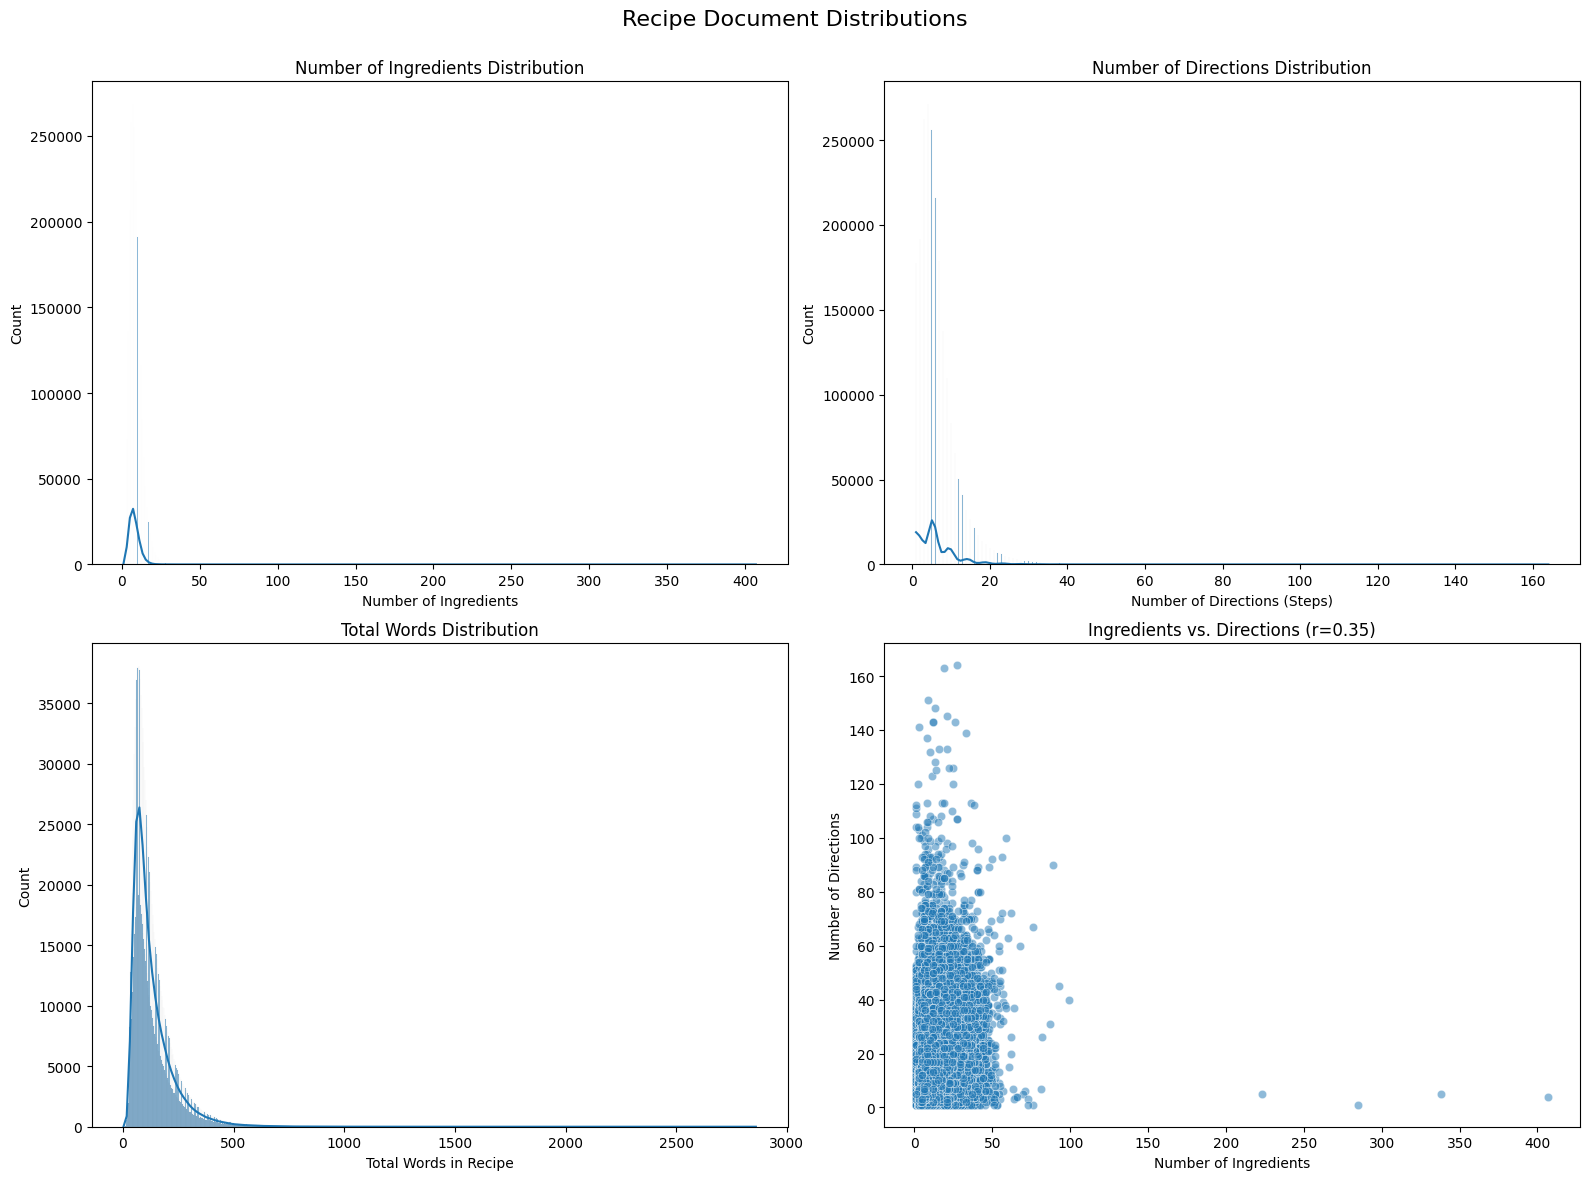

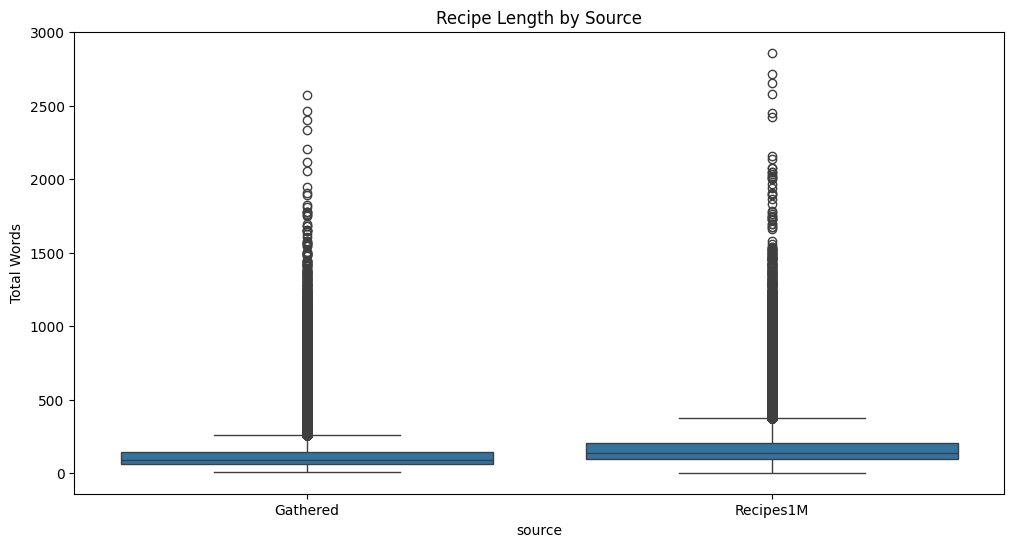


Very Short Recipes (≤3 steps): 631,785 (28.32%)
Very Long Recipes (≥16 steps): 130,970 (5.87%)


In [ ]:
def analyze_recipe_documents(df):
    """
    Analyze the recipes as documents: length, complexity, distributions
    """
    print("\n===== RECIPE DOCUMENT ANALYSIS =====")

    # Calculate document metrics
    print("Calculating document metrics...")

    # Add length metrics to DataFrame
     # Count NaN values in title column
    nan_count = df['title'].isna().sum()
    print(f"Found {nan_count} NaN values in the title column ({nan_count/len(df):.2%} of all records)")

    # Fill NaN values with empty strings
    df['title'] = df['title'].fillna('')

    # Calculate title length
    df['title_length'] = df['title'].apply(len)
    df['num_ingredients'] = df['ingredients'].apply(len)
    df['num_directions'] = df['directions'].apply(len)
    df['num_entities'] = df['NER'].apply(len)

    # Calculate word counts
    df['ingredients_words'] = df['ingredients'].apply(lambda x: sum(len(i.split()) for i in x))
    df['directions_words'] = df['directions'].apply(lambda x: sum(len(d.split()) for d in x))
    df['total_words'] = df['ingredients_words'] + df['directions_words'] + df['title'].apply(lambda x: len(x.split()))

    # Calculate average ingredient and direction lengths
    df['avg_ingredient_length'] = df.apply(lambda x: sum(len(i) for i in x['ingredients'])/len(x['ingredients']) if len(x['ingredients']) > 0 else 0, axis=1)
    df['avg_direction_length'] = df.apply(lambda x: sum(len(d) for d in x['directions'])/len(x['directions']) if len(x['directions']) > 0 else 0, axis=1)

    # Statistical summary of the document metrics
    metrics = ['title_length', 'num_ingredients', 'num_directions', 'num_entities',
               'ingredients_words', 'directions_words', 'total_words',
               'avg_ingredient_length', 'avg_direction_length']

    print("\nDocument Statistics:")
    for metric in metrics:
        print(f"\n{metric.replace('_', ' ').title()}:")
        print(f"  Mean: {df[metric].mean():.2f}")
        print(f"  Median: {df[metric].median():.2f}")
        print(f"  Standard Deviation: {df[metric].std():.2f}")
        print(f"  Min: {df[metric].min():.2f}")
        print(f"  Max: {df[metric].max():.2f}")

    # Distribution visualizations
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Recipe Document Distributions', fontsize=16)

    # Number of ingredients
    sns.histplot(df['num_ingredients'], kde=True, ax=axes[0, 0])
    axes[0, 0].set_title('Number of Ingredients Distribution')
    axes[0, 0].set_xlabel('Number of Ingredients')

    # Number of directions
    sns.histplot(df['num_directions'], kde=True, ax=axes[0, 1])
    axes[0, 1].set_title('Number of Directions Distribution')
    axes[0, 1].set_xlabel('Number of Directions (Steps)')

    # Total words
    sns.histplot(df['total_words'], kde=True, ax=axes[1, 0])
    axes[1, 0].set_title('Total Words Distribution')
    axes[1, 0].set_xlabel('Total Words in Recipe')

    # Correlation between ingredients and directions
    sns.scatterplot(data=df, x='num_ingredients', y='num_directions', alpha=0.5, ax=axes[1, 1])
    axes[1, 1].set_title(f'Ingredients vs. Dilenrections (r={df["num_ingredients"].corr(df["num_directions"]):.2f})')
    axes[1, 1].set_xlabel('Number of Ingredients')
    axes[1, 1].set_ylabel('Number of Directions')

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()

    # Document length distribution by source
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='source', y='total_words', data=df)
    plt.title('Recipe Length by Source')
    plt.ylabel('Total Words')
    plt.show()

    # Additional analysis on very short and very long recipes
    short_recipes = df[df['num_directions'] <= 3]
    long_recipes = df[df['num_directions'] >= df['num_directions'].quantile(0.95)]

    print(f"\nVery Short Recipes (≤3 steps): {len(short_recipes):,} ({len(short_recipes)/len(df)*100:.2f}%)")
    print(f"Very Long Recipes (≥{df['num_directions'].quantile(0.95):.0f} steps): {len(long_recipes):,} ({len(long_recipes)/len(df)*100:.2f}%)")



# Run the document analysis
analyze_recipe_documents(df)

## Filter data by source

This cell analyzes dataset sources and performs filtering:

* Displays source distribution in the dataset
  * Two sources identified: "Gathered" (1,643,098 recipes) and "Recipes1M" (588,044 recipes)
* Filters the dataset to keep only "Recipes1M" recipes
  * Original dataset: 2,231,142 recipes
  * Filtered dataset: 588,044 recipes (26.36% of original data)

In [ ]:
# The distribution of sources in your dataset
source_counts = df['source'].value_counts()
print("Source distribution:")
print(source_counts)

target_source = "Recipes1M"
# Filter the dataframe to keep only recipes from the target source
filtered_df = df[df['source'] == target_source]

# Check the size of your filtered dataset
print(f"\nOriginal dataset size: {len(df)} recipes")
print(f"Filtered dataset size: {len(filtered_df)} recipes")
print(f"Kept {len(filtered_df)/len(df)*100:.2f}% of the original data")

# Quick overview of the filtered dataset
print("\nFiltered dataset overview:")
print(filtered_df.info())

df = []

Source distribution:
source
Gathered     1643098
Recipes1M     588044
Name: count, dtype: int64

Original dataset size: 2231142 recipes
Filtered dataset size: 588044 recipes
Kept 26.36% of the original data

Filtered dataset overview:
<class 'pandas.core.frame.DataFrame'>
Index: 588044 entries, 1643098 to 2231141
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Unnamed: 0   588044 non-null  int64 
 1   title        588044 non-null  object
 2   ingredients  588044 non-null  object
 3   directions   588044 non-null  object
 4   link         588044 non-null  object
 5   source       588044 non-null  object
 6   NER          588044 non-null  object
dtypes: int64(1), object(6)
memory usage: 35.9+ MB
None


### save filterd data

In [ ]:
import os

# Define the path to save the filtered DataFrame
save_path = '/content/drive/MyDrive/rcp-nlp/filtered_recipes1m.pkl'

# Save the filtered DataFrame to a pickle file
filtered_df.to_pickle(save_path)

print(f"\nFiltered DataFrame saved to: {save_path}")
print(f"File size: {os.path.getsize(save_path):,} bytes")


Filtered DataFrame saved to: /content/drive/MyDrive/rcp-nlp/filtered_recipes1m.pkl
File size: 700,525,386 bytes


## Vocabulary Analysis (efficient - on filterd data)

This function performs optimized vocabulary analysis on recipe data:

* Samples recipes (if max_recipes parameter is provided)
* Processes recipe text, removing stop words and non-alphanumeric characters
* Tracks vocabulary statistics across:
  * All recipe text (title, ingredients, directions)
  * Ingredients specifically
  * Directions specifically
* Calculates and displays:
  * Total unique word counts for the entire collection
  * Unique word counts for ingredients and directions separately
  * Average and median vocabulary size per recipe
  * Top 15 most common words overall, in ingredients, and in directions
* Creates visualizations:
  * Histogram showing distribution of vocabulary sizes across recipes
  * Bar chart displaying the 20 most frequent words in the entire dataset
* Returns vocabulary data (total vocabulary, recipe vocabulary sizes, ingredient and direction vocabularies)

In [ ]:
import os
import pickle
import json
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm import tqdm
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import numpy as np

def analyze_vocabulary_optimized(df, max_recipes=None, output_dir="vocabulary_analysis"):
    """
    Analyze the vocabulary used in the recipes - optimized version
    Saves results to the specified directory
    """
    print("\n===== VOCABULARY ANALYSIS =====")

    # Create output directory if it doesn't exist
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        print(f"Created output directory: {output_dir}")

    # Use a smaller sample for detailed vocabulary analysis if dataset is large
    if max_recipes is not None:
        vocab_sample = df.sample(max_recipes, random_state=42)
        print(f"Using a sample of {max_recipes:,} recipes for vocabulary analysis")
    else:
        vocab_sample = df
        print(f"Using all {len(df):,} recipes for vocabulary analysis")

    # Initialize NLTK stop words
    stop_words = set(stopwords.words('english'))

    # Initialize counters and sets for global stats
    all_word_counter = Counter()
    ingredient_word_counter = Counter()
    direction_word_counter = Counter()
    recipe_vocab_sizes = []
    ingredient_vocab = set()
    direction_vocab = set()

    # Process text in bulk with vectorized operations where possible
    print("Processing recipes for vocabulary analysis...")

    # Process each recipe with better efficiency
    for index, row in tqdm(vocab_sample.iterrows(), total=len(vocab_sample)):
        # Create sets for this recipe's unique words
        recipe_words_set = set()

        # Process title - do once per row
        if isinstance(row['title'], str):
            title_tokens = [w.lower() for w in word_tokenize(row['title'])
                           if w.isalnum() and w.lower() not in stop_words]
            recipe_words_set.update(title_tokens)
            all_word_counter.update(title_tokens)

        # Process ingredients - batch process all ingredients for this recipe
        ing_words = []
        if isinstance(row['ingredients'], list):
            for ingredient in row['ingredients']:
                if isinstance(ingredient, str):
                    tokens = [w.lower() for w in word_tokenize(ingredient)
                             if w.isalnum() and w.lower() not in stop_words]
                    ing_words.extend(tokens)

            recipe_words_set.update(ing_words)
            ingredient_word_counter.update(ing_words)
            all_word_counter.update(ing_words)
            ingredient_vocab.update(ing_words)

        # Process directions - batch process all directions for this recipe
        dir_words = []
        if isinstance(row['directions'], list):
            for direction in row['directions']:
                if isinstance(direction, str):
                    tokens = [w.lower() for w in word_tokenize(direction)
                             if w.isalnum() and w.lower() not in stop_words]
                    dir_words.extend(tokens)

            recipe_words_set.update(dir_words)
            direction_word_counter.update(dir_words)
            all_word_counter.update(dir_words)
            direction_vocab.update(dir_words)

        # Store the vocabulary size for this recipe
        recipe_vocab_sizes.append(len(recipe_words_set))

    # Calculate vocabulary statistics
    total_vocab = set(all_word_counter.keys())

    # Save vocabulary statistics to a text file
    stats_file = os.path.join(output_dir, "vocabulary_statistics.txt")
    with open(stats_file, 'w') as f:
        f.write("VOCABULARY SIZE STATISTICS:\n")
        f.write(f"  Total collection vocabulary: {len(total_vocab):,} unique words\n")
        f.write(f"  Ingredient vocabulary: {len(ingredient_vocab):,} unique words\n")
        f.write(f"  Direction vocabulary: {len(direction_vocab):,} unique words\n")
        f.write(f"  Average vocabulary per recipe: {np.mean(recipe_vocab_sizes):.2f} unique words\n")
        f.write(f"  Median vocabulary per recipe: {np.median(recipe_vocab_sizes):.2f} unique words\n\n")

        f.write("MOST COMMON WORDS OVERALL:\n")
        for word, count in all_word_counter.most_common(15):
            f.write(f"  {word}: {count:,}\n")

        f.write("\nMOST COMMON INGREDIENT WORDS:\n")
        for word, count in ingredient_word_counter.most_common(15):
            f.write(f"  {word}: {count:,}\n")

        f.write("\nMOST COMMON DIRECTION WORDS:\n")
        for word, count in direction_word_counter.most_common(15):
            f.write(f"  {word}: {count:,}\n")

    print(f"Saved vocabulary statistics to {stats_file}")

    # Print stats to console as well
    print("\nVocabulary Size Statistics:")
    print(f"  Total collection vocabulary: {len(total_vocab):,} unique words")
    print(f"  Ingredient vocabulary: {len(ingredient_vocab):,} unique words")
    print(f"  Direction vocabulary: {len(direction_vocab):,} unique words")
    print(f"  Average vocabulary per recipe: {np.mean(recipe_vocab_sizes):.2f} unique words")
    print(f"  Median vocabulary per recipe: {np.median(recipe_vocab_sizes):.2f} unique words")

    # Most common words analysis
    print("\nMost Common Words Overall:")
    for word, count in all_word_counter.most_common(15):
        print(f"  {word}: {count:,}")

    print("\nMost Common Ingredient Words:")
    for word, count in ingredient_word_counter.most_common(15):
        print(f"  {word}: {count:,}")

    print("\nMost Common Direction Words:")
    for word, count in direction_word_counter.most_common(15):
        print(f"  {word}: {count:,}")

    # Visualize vocabulary distribution and save to file
    plt.figure(figsize=(12, 6))
    sns.histplot(recipe_vocab_sizes, kde=True)
    plt.title('Distribution of Vocabulary Size per Recipe')
    plt.xlabel('Number of Unique Words')
    plt.ylabel('Number of Recipes')
    plt.axvline(x=np.mean(recipe_vocab_sizes), color='r', linestyle='--', label=f'Mean: {np.mean(recipe_vocab_sizes):.2f}')
    plt.axvline(x=np.median(recipe_vocab_sizes), color='g', linestyle='--', label=f'Median: {np.median(recipe_vocab_sizes):.2f}')
    plt.legend()
    plt.tight_layout()

    # Save figure
    vocab_dist_file = os.path.join(output_dir, "vocabulary_distribution.png")
    plt.savefig(vocab_dist_file, dpi=300)
    plt.close()
    print(f"Saved vocabulary distribution plot to {vocab_dist_file}")

    # Visualize top words and save to file
    plt.figure(figsize=(12, 6))

    # Get top words
    top_words = [word for word, _ in all_word_counter.most_common(20)]
    top_counts = [all_word_counter[word] for word in top_words]

    # Create bar plot
    plt.bar(range(len(top_words)), top_counts)

    # Customize plot
    plt.xticks(range(len(top_words)), top_words, rotation=45, ha='right')
    plt.title('Top 20 Most Frequent Words in Recipes')
    plt.xlabel('Word')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

    # Save figure
    top_words_file = os.path.join(output_dir, "top_words.png")
    plt.savefig(top_words_file, dpi=300)
    plt.close()
    print(f"Saved top words plot to {top_words_file}")

    # Save word frequency counts as JSON
    word_counts = {
        'all_words': dict(all_word_counter.most_common(1000)),
        'ingredient_words': dict(ingredient_word_counter.most_common(1000)),
        'direction_words': dict(direction_word_counter.most_common(1000))
    }

    word_counts_file = os.path.join(output_dir, "word_frequencies.json")
    with open(word_counts_file, 'w') as f:
        json.dump(word_counts, f, indent=2)
    print(f"Saved word frequencies to {word_counts_file}")

    # Save vocabulary sets as pickle files
    vocab_data = {
        'total_vocab': list(total_vocab),
        'recipe_vocab_sizes': recipe_vocab_sizes,
        'ingredient_vocab': list(ingredient_vocab),
        'direction_vocab': list(direction_vocab)
    }

    vocab_pickle_file = os.path.join(output_dir, "vocabulary_data.pkl")
    with open(vocab_pickle_file, 'wb') as f:
        pickle.dump(vocab_data, f)
    print(f"Saved vocabulary data to {vocab_pickle_file}")

    # Return vocabulary information for further analysis
    return total_vocab, recipe_vocab_sizes, ingredient_vocab, direction_vocab

# Run the vocabulary analysis with output directory specified
total_vocab, recipe_vocab_sizes, ingredient_vocab, direction_vocab = analyze_vocabulary_optimized(
    filtered_df,
    max_recipes=None,  # Set to your desired sample size
    output_dir="SaSha/recipe_vocabulary_analysis"
)


===== VOCABULARY ANALYSIS =====
Using all 588,044 recipes for vocabulary analysis
Processing recipes for vocabulary analysis...


100%|██████████| 588044/588044 [23:29<00:00, 417.29it/s]


Saved vocabulary statistics to recipe_vocabulary_analysis/vocabulary_statistics.txt

Vocabulary Size Statistics:
  Total collection vocabulary: 127,101 unique words
  Ingredient vocabulary: 41,965 unique words
  Direction vocabulary: 87,185 unique words
  Average vocabulary per recipe: 73.42 unique words
  Median vocabulary per recipe: 67.00 unique words

Most Common Words Overall:
  1: 2,337,737
  2: 1,259,048
  cup: 1,131,463
  add: 886,509
  minutes: 716,943
  salt: 677,065
  heat: 604,353
  pepper: 565,612
  teaspoon: 553,378
  oil: 548,497
  3: 485,069
  sugar: 474,932
  tablespoons: 449,751
  butter: 448,324
  cups: 439,871

Most Common Ingredient Words:
  1: 1,986,694
  cup: 984,779
  2: 964,841
  teaspoon: 509,221
  tablespoons: 386,617
  cups: 379,436
  chopped: 375,221
  12: 364,490
  salt: 335,165
  3: 319,035
  pepper: 298,871
  4: 265,639
  sugar: 242,917
  oil: 241,264
  fresh: 226,123

Most Common Direction Words:
  add: 883,488
  minutes: 714,738
  heat: 602,971
  bowl:

<img src="https://i.postimg.cc/qqgS8fBj/vocabulary-distribution.png" alt="An example image"  width= 700>

<img src="https://i.postimg.cc/pL9j3sr4/top-words.png" alt="An example image" width=700>


## Cuisine Classification

This section implements an automated recipe cuisine classifier that can identify different cuisine types based on recipe content.

**Implementation Overview**

- **Goal**: Build a machine learning model that can accurately **identify the cuisine type of recipes** based on their **ingredients, preparation methods, and vocabulary patterns**.

- **Key steps**:
  * **Data preparation**: Identifies cuisine types by analyzing recipe titles and ingredients against cuisine-specific keyword dictionaries
  * **Feature extraction**: Creates TF-IDF representations of recipes with memory-optimized batch processing to handle large datasets
  * **Vocabulary analysis**: Calculates metrics like vocabulary size, lexical density, and average word length
  * **Classification**: Implements a Random Forest classifier to predict cuisine type from extracted features
  * **Evaluation**: Measures classification performance using precision, recall, and F1-score

- **Implementation highlights**:
  * Memory optimization techniques for processing large recipe datasets
  * Persistent storage of intermediate results to enable efficient retraining
  * Multi-dimensional feature representation combining text and statistical measures

### loading recipe dataframe and vocabulary

- **Memory-Efficient Data Loading**:
  * Loads pre-processed vocabulary data from pickle file instead of recomputing
  * Imports filtered dataset (1M recipes) from pickle file to reduce memory usage
  * Loads pre-calculated word frequencies from JSON

- **Vocabulary Extraction**:
  * Creates sets for total vocabulary, ingredient-specific vocabulary, and directions vocabulary
  * Stores recipe vocabulary sizes for analysis

- **Dataset Verification**:
  * Prints the filtered DataFrame's file path and shape
  * Displays first 5 rows to verify data integrity

- **Note**: Using pre-processed files significantly reduces computational overhead and memory requirements compared to processing raw data

In [ ]:
import pickle
import json
import matplotlib.pyplot as plt
import pandas as pd


# Load vocabulary data from pickle file
with open("SaSha/recipe_vocabulary_analysis/vocabulary_data.pkl", "rb") as f:
    vocab_data = pickle.load(f)

total_vocab = set(vocab_data['total_vocab'])
recipe_vocab_sizes = vocab_data['recipe_vocab_sizes']
ingredient_vocab = set(vocab_data['ingredient_vocab'])
direction_vocab = set(vocab_data['direction_vocab'])

# Load word frequencies from JSON
with open("SaSha/recipe_vocabulary_analysis/word_frequencies.json", "r") as f:
    word_counts = json.load(f)

# load filtered_df from the directory

# Define the path to load the filtered DataFrame
load_path = '/content/drive/MyDrive/rcp-nlp/filtered_recipes1m.pkl'

# Load the filtered DataFrame from the pickle file
filtered_df = pd.read_pickle(load_path)

print(f"Filtered DataFrame loaded from: {load_path}")
print(f"Filtered dataset shape: {filtered_df.shape}")

# Display the first few rows of the loaded DataFrame
print("\nFirst 5 rows of the loaded DataFrame:")
print(filtered_df.head())

Filtered DataFrame loaded from: /content/drive/MyDrive/rcp-nlp/filtered_recipes1m.pkl
Filtered dataset shape: (588044, 7)

First 5 rows of the loaded DataFrame:
         Unnamed: 0                            title  \
1643098     1643098       Worlds Best Mac and Cheese   
1643099     1643099      Dilly Macaroni Salad Recipe   
1643100     1643100                         Gazpacho   
1643101     1643101  Kombu Tea Grilled Chicken Thigh   
1643102     1643102               Zucchini Nut Bread   

                                               ingredients  \
1643098  [6 ounces penne, 2 cups Beechers Flagship Chee...   
1643099  [1 c. elbow macaroni, 1 c. cubed American chee...   
1643100  [8 tomatoes, quartered, Kosher salt, 1 red oni...   
1643101  [2 Chicken thighs, 2 tsp Kombu tea, 1 White pe...   
1643102  [2 cups flour, 1 tablespoon cinnamon, 2 teaspo...   

                                                directions  \
1643098  [Preheat the oven to 350 F. Butter or oil an 8...   
16430

### Data preparation

**Cuisine Labeling Implementation**:
- **Cuisine Dictionary Creation**:
  * Builds comprehensive dictionaries of cuisine-specific keywords for 15 distinct cuisines
  * Each cuisine has 35-45 characteristic ingredients, dishes, and cooking techniques
  * Includes major world cuisines: Italian, Mexican, Chinese, Indian, French, Japanese, Thai, American, etc.

- **Intelligent Cuisine Classification Algorithm**:
  * Analyzes recipe title, ingredients list, and cooking directions for cuisine markers
  * Scores each potential cuisine based on keyword matches with weighted scoring
  * Implements minimum threshold to avoid weak classifications
  * Labels recipes without strong cuisine signals as "other"

- **Data Filtering and Quality Control**:
  * Generates distribution statistics of identified cuisines
  * Removes underrepresented cuisines (fewer than 50 examples)
  * Returns a filtered dataset containing only recipes with reliable cuisine labels
  * Displays dataset size metrics before and after filtering

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.util import ngrams

filtered_df_sample = filtered_df.copy()

def prepare_cuisine_data(df, required_score=3, cuisine_column='cuisine', min_examples = 50):
    """
    Prepare the dataset for cuisine classification
    If cuisine isn't in your data, this function will attempt to infer it from the title or create a dummy column
    """
    # Check if cuisine column exists, otherwise try to create it
    if cuisine_column not in df.columns:
        print(f"'{cuisine_column}' column not found. Attempting to infer cuisines from recipe titles...")

        # Define common cuisine keywords
        cuisine_keywords = {
                'italian': [
                    'italian', 'pasta', 'pizza', 'risotto', 'lasagna', 'spaghetti', 'fettuccine', 'ravioli',
                    'carbonara', 'parmigiana', 'gnocchi', 'cannelloni', 'pesto', 'bruschetta', 'tiramisu',
                    'panna cotta', 'bolognese', 'minestrone', 'prosciutto', 'pancetta', 'ciabatta', 'focaccia',
                    'polenta', 'arancini', 'mascarpone', 'ricotta', 'mozzarella', 'parmigiano', 'pecorino',
                    'gelato', 'biscotti', 'cannoli', 'calzone', 'antipasto', 'marsala', 'osso buco', 'tortellini'
                ],

                'mexican': [
                    'mexican', 'taco', 'burrito', 'enchilada', 'quesadilla', 'tortilla', 'salsa', 'guacamole',
                    'nachos', 'chimichanga', 'fajita', 'tamale', 'tostada', 'mole', 'pozole', 'carnitas',
                    'churro', 'cilantro', 'jalapeno', 'habanero', 'chipotle', 'queso', 'chalupa', 'pico de gallo',
                    'sopapilla', 'horchata', 'margarita', 'tequila', 'chili relleno', 'mole poblano', 'tres leches',
                    'chile', 'menudo', 'flautas', 'chorizo', 'ceviche', 'empanada', 'refried beans', 'poblano'
                ],

                'chinese': [
                    'chinese', 'stir fry', 'wok', 'dumpling', 'noodle', 'dim sum', 'kung pao', 'lo mein',
                    'chow mein', 'fried rice', 'spring roll', 'egg roll', 'pot sticker', 'wonton', 'szechuan',
                    'hoisin', 'oyster sauce', 'five spice', 'soy sauce', 'tofu', 'chop suey', 'peking duck',
                    'bao', 'ginger beef', 'sesame chicken', 'mongolian', 'char siu', 'mapo tofu', 'rice wine',
                    'xiao long bao', 'congee', 'chow fun', 'jiaozi', 'egg drop soup', 'hot pot', 'glass noodle',
                    'bok choy', 'chinese broccoli', 'snow pea', 'black bean sauce', 'scallion pancake', 'har gow'
                ],

                'indian': [
                    'indian', 'curry', 'masala', 'naan', 'tandoori', 'tikka', 'biryani', 'dal', 'paneer',
                    'chutney', 'samosa', 'vindaloo', 'korma', 'chapati', 'roti', 'garam masala', 'ghee',
                    'raita', 'lassi', 'chai', 'cardamom', 'cumin', 'turmeric', 'coriander', 'saag', 'aloo',
                    'gobi', 'dosa', 'idli', 'pakora', 'malai', 'coconut chutney', 'tamarind', 'pudina',
                    'papadum', 'jalebi', 'ladoo', 'gulab jamun', 'chaat', 'bhaji', 'palak', 'mughlai', 'butter chicken'
                ],

                'french': [
                    'french', 'ratatouille', 'croissant', 'souffle', 'cassoulet', 'bechamel', 'baguette',
                    'crepe', 'quiche', 'coq au vin', 'escargot', 'foie gras', 'bouillabaisse', 'hollandaise',
                    'creme brulee', 'profiterole', 'eclair', 'macaron', 'creme fraiche', 'confit', 'frisee',
                    'gratin', 'haricot vert', 'boeuf bourguignon', 'brie', 'camembert', 'charcuterie', 'mille feuille',
                    'tarte tatin', 'madeleines', 'pain au chocolat', 'brioche', 'dijon', 'duxelles', 'bearnaise',
                    'beurre blanc', 'pate', 'roux', 'clafoutis', 'galette', 'meringue', 'mousse', 'provencal'
                ],

                'mediterranean': [
                    'mediterranean', 'greek', 'hummus', 'falafel', 'tahini', 'pita', 'tzatziki', 'olive oil',
                    'kalamata', 'spanakopita', 'gyro', 'souvlaki', 'moussaka', 'baklava', 'dolma', 'feta',
                    'couscous', 'tabbouleh', 'baba ganoush', 'shawarma', 'halloumi', 'orzo', 'grape leaf',
                    'mediterranean salad', 'calamari', 'eggplant dip', 'kebab', 'grilled octopus', 'lamb',
                    'yogurt sauce', 'ouzo', 'pastitsio', 'avgolemono', 'horiatiki', 'phyllo', 'taramasalata',
                    'meze', 'spanish tapas', 'paella', 'gazpacho', 'harissa', 'sumac', 'za\'atar'
                ],

                'japanese': [
                    'japanese', 'sushi', 'teriyaki', 'tempura', 'ramen', 'sashimi', 'miso', 'udon', 'soba',
                    'yakitori', 'onigiri', 'wasabi', 'bento', 'gyoza', 'katsu', 'edamame', 'dashi', 'donburi',
                    'yakiniku', 'ponzu', 'shabu shabu', 'okonomiyaki', 'takoyaki', 'unagi', 'tamago', 'nigiri',
                    'maki', 'tonkatsu', 'sukiyaki', 'matcha', 'mochi', 'wagyu', 'togarashi', 'karaage',
                    'daikon', 'yuzu', 'sake', 'shoyu', 'umeboshi', 'furikake', 'tamagoyaki', 'shiitake',
                    'wakame', 'nori', 'buri', 'bonito', 'gyudon', 'ochazuke', 'ikura', 'dorayaki'
                ],

                'thai': [
                    'thai', 'curry', 'pad thai', 'satay', 'tom yum', 'fish sauce', 'galangal', 'lemongrass',
                    'thai basil', 'kaffir lime', 'coconut milk', 'green curry', 'red curry', 'yellow curry',
                    'massaman curry', 'pad see ew', 'pad kee mao', 'tom kha', 'larb', 'papaya salad', 'panang',
                    'spring roll', 'mango sticky rice', 'pad kra pao', 'thai iced tea', 'nam prik',
                    'sriracha', 'nam pla', 'tamarind paste', 'pad woon sen', 'prik nam pla', 'gaeng', 'yam',
                    'pla', 'hom mali rice', 'jasmine rice', 'khao soi', 'khao pad', 'gai yang', 'panaeng'
                ],

                'american': [
                    'american', 'burger', 'barbecue', 'bbq', 'sandwich', 'hot dog', 'steak', 'fried chicken',
                    'meatloaf', 'macaroni and cheese', 'mac and cheese', 'biscuit', 'gravy', 'apple pie',
                    'chocolate chip cookie', 'buffalo wing', 'cornbread', 'coleslaw', 'chowder', 'clam chowder',
                    'grilled cheese', 'pot roast', 'potato salad', 'pancake', 'waffle', 'casserole', 'cobbler',
                    'bourbon', 'cajun', 'creole', 'jambalaya', 'gumbo', 'hush puppy', 'corn dog', 'chili',
                    'pulled pork', 'salisbury steak', 'ranch dressing', 's\'more', 'peanut butter', 'jelly'
                ],

                'korean': [
                    'korean', 'kimchi', 'bibimbap', 'bulgogi', 'gochujang', 'doenjang', 'gochugaru', 'banchan',
                    'galbi', 'kalbi', 'jjigae', 'tteokbokki', 'japchae', 'kimbap', 'sundubu', 'pajeon', 'mandu',
                    'samgyeopsal', 'kochujang', 'samgyetang', 'jajangmyeon', 'makgeolli', 'soju', 'bindaetteok',
                    'kongnamul', 'miyeok', 'naengmyeon', 'bo ssam', 'korean fried chicken', 'dakgalbi', 'hotteok',
                    'dak', 'yangnyeom', 'kalguksu', 'seolleongtang', 'yukhoe', 'bossam', 'budae jjigae', 'hobak'
                ],

                'vietnamese': [
                    'vietnamese', 'pho', 'banh mi', 'nuoc mam', 'rice noodle', 'spring roll', 'rice paper',
                    'vietnamese coffee', 'banh xeo', 'bun bo hue', 'cha gio', 'goi cuon', 'nuoc cham', 'hoisin',
                    'sriracha', 'fish sauce', 'lemongrass', 'bun thit nuong', 'cao lau', 'bo kho', 'ca kho to',
                    'cao lau', 'nem nuong', 'vietnamese mint', 'vietnamese cinnamon', 'thit kho', 'ca ri ga',
                    'bun rieu', 'mi quang', 'hu tieu', 'com tam', 'bo la lot', 'canh chua', 'cha ca', 'trung vit lon'
                ],

                'middle_eastern': [
                    'middle eastern', 'kebab', 'tabbouleh', 'shawarma', 'falafel', 'hummus', 'pita', 'baba ganoush',
                    'couscous', 'za\'atar', 'sumac', 'tahini', 'harissa', 'dolma', 'muhammara', 'labneh', 'halva',
                    'baklava', 'kibbeh', 'fattoush', 'kanafeh', 'shish tawook', 'tabouli', 'mujadara', 'manakish',
                    'mansaf', 'rosewater', 'pomegranate molasses', 'dukkah', 'ful medames', 'mahlab', 'saffron',
                    'tagine', 'kofta', 'shakshouka', 'borek', 'ras el hanout', 'maftoul', 'freekeh', 'lavash'
                ],

                'spanish': [
                    'spanish', 'paella', 'tapas', 'gazpacho', 'chorizo', 'tortilla espanola', 'jamon', 'serrano',
                    'manchego', 'sangria', 'saffron', 'piquillo', 'romesco', 'aioli', 'membrillo', 'rioja',
                    'croquetas', 'patatas bravas', 'empanada', 'gambas', 'flan', 'churros', 'calamares',
                    'pulpo a la gallega', 'pimientos de padron', 'boquerones', 'alioli', 'cava', 'callos',
                    'cocido madrileno', 'escalivada', 'fabada', 'fideos', 'mojo', 'sobrasada', 'turron', 'txakoli'
                ],

                'german': [
                    'german', 'sauerkraut', 'bratwurst', 'schnitzel', 'pretzel', 'spaetzle', 'sauerbraten',
                    'strudel', 'rouladen', 'lebkuchen', 'weisswurst', 'pumpernickel', 'knodel', 'marzipan',
                    'black forest', 'beer', 'pilsner', 'hefeweizen', 'bock', 'knoedel', 'kassler', 'currywurst',
                    'jagerschnitzel', 'wiener', 'rollmops', 'bavarian', 'thuringer', 'frankfurter', 'frikadellen',
                    'blutwurst', 'leberkaese', 'brezel', 'eintopf', 'fleischsalat', 'schweinshaxe', 'gulasch'
                ],

                'caribbean': [
                    'caribbean', 'jerk', 'plantain', 'rice and peas', 'callaloo', 'ackee', 'saltfish', 'roti',
                    'curry goat', 'rum punch', 'sorrel', 'ginger beer', 'pineapple', 'mango', 'coconut',
                    'conch', 'bammy', 'jamaican patty', 'mofongo', 'arroz con gandules', 'tostones', 'coco bread',
                    'cassava', 'allspice', 'scotch bonnet', 'oxtail', 'reggae', 'chutney', 'goat curry',
                    'macaroni pie', 'johnny cake', 'soursop', 'guava', 'mamajuana', 'griot', 'doubles', 'cou cou'
                ]
            }

        # Function to identify cuisine from title and ingredients
        def identify_cuisine(row):
            title = row['title'].lower() if isinstance(row['title'], str) else ""
            ingredients_text = ' '.join(row['ingredients']).lower() if isinstance(row['ingredients'], list) else ""
            directions_text = ' '.join(row['directions']).lower() if isinstance(row['directions'], list) else ""

            # Combined text with more weight on title and ingredients
            text = title + " " + ingredients_text + " " + directions_text

            # Count matches for each cuisine
            cuisine_scores = {}

            for cuisine, keywords in cuisine_keywords.items():
                # Count how many keywords match
                matches = sum(1 for keyword in keywords if keyword in text)
                # Calculate score based on number of matches and specificity of keywords
                cuisine_scores[cuisine] = matches * (1.0 + 0.1 * len(keywords))

            # Get the cuisine with highest score
            max_score = max(cuisine_scores.values()) if cuisine_scores else 0
            best_cuisine = max(cuisine_scores.items(), key=lambda x: x[1])[0] if cuisine_scores else 'other'

            # Only classify as a specific cuisine if we have a strong enough signal
            # This threshold can be adjusted based on how aggressively you want to classify
            if max_score >= required_score:
                return best_cuisine
            else:
                return 'other'

        # Apply function to create cuisine column
        df[cuisine_column] = df.apply(identify_cuisine, axis=1)

    # Display cuisine distribution
    cuisine_counts = df[cuisine_column].value_counts()
    print("\nCuisine Distribution:")
    print(cuisine_counts)

    # Filter out cuisines with too few examples (optional)
    valid_cuisines = cuisine_counts[cuisine_counts >= min_examples].index
    filtered_cuisine_df = df[df[cuisine_column].isin(valid_cuisines)].copy()

    print(f"\nKeeping {len(valid_cuisines)} cuisines with at least {min_examples} examples each")
    print(f"Dataset size after filtering: {len(filtered_cuisine_df)} recipes")

    return filtered_cuisine_df

# Prepare dataset with cuisine information
cuisine_df = prepare_cuisine_data(filtered_df_sample, required_score=2, min_examples= 1000)

'cuisine' column not found. Attempting to infer cuisines from recipe titles...

Cuisine Distribution:
cuisine
other             94501
thai              92881
american          90928
mediterranean     74348
french            47070
italian           38803
mexican           36868
indian            34070
chinese           30640
japanese          26555
caribbean         14872
german             3018
spanish            1792
vietnamese          845
middle_eastern      564
korean              289
Name: count, dtype: int64

Keeping 13 cuisines with at least 1000 examples each
Dataset size after filtering: 586346 recipes


### Feature Extraction and Vocabulary Analysis (Memory Optimized)



- **Text Representation Creation**:
  * Combines recipe title, ingredients, and directions into a unified text representation
  * Converts list fields to strings for consistent processing
  * Creates a comprehensive "full_text" field for feature extraction

- **Statistical Feature Extraction**:
  * Calculates three vocabulary richness metrics for each recipe:
    - Vocabulary size (unique word count)
    - Vocabulary density (ratio of unique words to total words)
    - Average word length (character count mean)
  * Stores metrics in a separate DataFrame to reduce memory usage

- **Memory-Optimized TF-IDF Implementation**:
  * Uses TfidfVectorizer with reduced dimensionality (3,000 features)
  * Applies filters to remove rare terms (min_df=10) and common stopwords
  * Processes large datasets in configurable batches (200,000 recipes per batch)
  * Implements garbage collection between batches to free memory

- **Data Persistence Strategy**:
  * Saves feature matrices in sparse format to minimize storage requirements
  * Creates train/test split (80/20) with stratification by cuisine type
  * Stores all extracted features and metadata to disk for future use
  * Generates a comprehensive dataset info file with distribution statistics

In [ ]:
def extract_vocabulary_features_memory_optimized(df, cuisine_column='cuisine', output_dir="SaSha/features_output", batch_size=1000):
    """
    Extract vocabulary-based features for cuisine classification
    Optimized for memory usage with large datasets
    """
    import os
    import gc
    import numpy as np
    import pandas as pd
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.model_selection import train_test_split
    from scipy import sparse

    print("\n===== EXTRACTING VOCABULARY FEATURES (MEMORY OPTIMIZED) =====")

    # Create output directory if it doesn't exist
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        print(f"Created output directory: {output_dir}")

    # 1. Create combined text field for each recipe
    print("Creating text representations...")

    df['ingredients_text'] = df['ingredients'].apply(lambda x: ' '.join(x) if isinstance(x, list) else '')
    df['directions_text'] = df['directions'].apply(lambda x: ' '.join(x) if isinstance(x, list) else '')
    df['full_text'] = df['title'] + ' ' + df['ingredients_text'] + ' ' + df['directions_text']

    # 2. Calculate vocabulary metrics first (lower memory usage)
    print("Creating vocabulary richness features...")

    def calculate_vocab_metrics(text):
        if not text or not isinstance(text, str):
            return 0, 0, 0

        words = text.lower().split()
        if not words:
            return 0, 0, 0

        unique_words = set(words)
        return len(unique_words), len(unique_words)/len(words), sum(len(w) for w in words)/len(words)

    # Create a separate DataFrame for these metrics to save memory
    vocab_metrics_df = pd.DataFrame(index=df.index)
    vocab_metrics_df['vocab_size'], vocab_metrics_df['vocab_density'], vocab_metrics_df['avg_word_length'] = zip(
        *df['full_text'].apply(calculate_vocab_metrics)
    )

    # Save vocabulary metrics to disk
    vocab_metrics_file = os.path.join(output_dir, "vocab_metrics.csv")
    vocab_metrics_df.to_csv(vocab_metrics_file)
    print(f"Saved vocabulary metrics to {vocab_metrics_file}")

    # 3. TF-IDF Features with reduced dimensionality
    print("Generating TF-IDF features...")

    # Use fewer features to save memory
    tfidf_vectorizer = TfidfVectorizer(
        max_features=3000,  # Reduced from 5000
        min_df=10,          # Increased from 5
        stop_words='english',
        ngram_range=(1, 2)  # Only unigrams to save memory
    )

    # Process TF-IDF in batches to save memory
    print("Processing TF-IDF in batches...")
    total_batches = (len(df) + batch_size - 1) // batch_size

    # Initialize the sparse matrix list
    X_tfidf_parts = []
    batch_indices = []

    for i in range(total_batches):
        start_idx = i * batch_size
        end_idx = min((i + 1) * batch_size, len(df))

        print(f"Processing batch {i+1}/{total_batches} (records {start_idx}-{end_idx})...")
        batch_df = df.iloc[start_idx:end_idx]

        if i == 0:
            # Fit on first batch, transform on all batches
            X_batch = tfidf_vectorizer.fit_transform(batch_df['full_text'])
            feature_names = tfidf_vectorizer.get_feature_names_out()

            # Save feature names
            with open(os.path.join(output_dir, "tfidf_feature_names.txt"), 'w') as f:
                for name in feature_names:
                    f.write(f"{name}\n")
        else:
            # Transform only for subsequent batches
            X_batch = tfidf_vectorizer.transform(batch_df['full_text'])

        # Save the batch indices and add the sparse matrix to our list
        batch_indices.extend(batch_df.index.tolist())
        X_tfidf_parts.append(X_batch)

        # Force garbage collection
        gc.collect()

    # Split data for training and testing
    print("Splitting data for training and testing...")

    # Get cuisine labels
    y = df[cuisine_column]

    # Create indices for train/test split
    indices = np.arange(len(df))
    train_indices, test_indices, y_train, y_test = train_test_split(
        indices, y, test_size=0.2, random_state=42, stratify=y
    )

    # Save labels
    pd.Series(y_train, name='cuisine').to_csv(os.path.join(output_dir, "y_train.csv"))
    pd.Series(y_test, name='cuisine').to_csv(os.path.join(output_dir, "y_test.csv"))
    print(f"Saved train/test labels to {output_dir}")

    # Save vocabulary metrics for train/test sets
    vocab_metrics_df.iloc[train_indices].to_csv(os.path.join(output_dir, "vocab_metrics_train.csv"))
    vocab_metrics_df.iloc[test_indices].to_csv(os.path.join(output_dir, "vocab_metrics_test.csv"))

    # Save TF-IDF features in sparse format
    print("Saving TF-IDF features in sparse format...")

    # Combine all batches into one sparse matrix
    X_tfidf = sparse.vstack(X_tfidf_parts)

    # Save the combined sparse matrix
    sparse.save_npz(os.path.join(output_dir, "X_tfidf_all.npz"), X_tfidf)

    # Save train/test TF-IDF features
    X_train_tfidf = X_tfidf[train_indices]
    X_test_tfidf = X_tfidf[test_indices]

    sparse.save_npz(os.path.join(output_dir, "X_train_tfidf.npz"), X_train_tfidf)
    sparse.save_npz(os.path.join(output_dir, "X_test_tfidf.npz"), X_test_tfidf)

    print(f"Saved TF-IDF features to {output_dir}")
    print(f"Train set: {X_train_tfidf.shape[0]} samples, {X_train_tfidf.shape[1]} features")
    print(f"Test set: {X_test_tfidf.shape[0]} samples, {X_test_tfidf.shape[1]} features")

    # Save dataset information
    info = {
        'num_samples': len(df),
        'num_features': X_tfidf.shape[1],
        'feature_types': ['tfidf', 'vocab_metrics'],
        'train_size': len(train_indices),
        'test_size': len(test_indices),
        'cuisine_distribution': y.value_counts().to_dict()
    }

    pd.Series(info).to_json(os.path.join(output_dir, "dataset_info.json"))

    print("\nFeature extraction complete. All data saved to disk.")
    print(f"To load the data, use: X_train = sparse.load_npz('{os.path.join(output_dir, 'X_train_tfidf.npz')}')")

    return train_indices, test_indices

# Usage:
train_indices, test_indices = extract_vocabulary_features_memory_optimized(
    cuisine_df,
    cuisine_column='cuisine',
    output_dir="SaSha/cuisine_features",
    batch_size=200000  # Adjust based on your available memory
)


===== EXTRACTING VOCABULARY FEATURES (MEMORY OPTIMIZED) =====
Creating text representations...
Creating vocabulary richness features...
Saved vocabulary metrics to SaSha/cuisine_features/vocab_metrics.csv
Generating TF-IDF features...
Processing TF-IDF in batches...
Processing batch 1/3 (records 0-200000)...
Processing batch 2/3 (records 200000-400000)...
Processing batch 3/3 (records 400000-586346)...
Splitting data for training and testing...
Saved train/test labels to SaSha/cuisine_features
Saving TF-IDF features in sparse format...
Saved TF-IDF features to SaSha/cuisine_features
Train set: 469076 samples, 3000 features
Test set: 117270 samples, 3000 features

Feature extraction complete. All data saved to disk.
To load the data, use: X_train = sparse.load_npz('SaSha/cuisine_features/X_train_tfidf.npz')


In [ ]:
# !zip -r SaSha/cuisine_features/file.zip SaSha/cuisine_features/

  adding: SaSha/cuisine_features/ (stored 0%)
  adding: SaSha/cuisine_features/vocab_metrics.csv (deflated 70%)
  adding: SaSha/cuisine_features/tfidf_feature_names.txt (deflated 66%)
  adding: SaSha/cuisine_features/y_train.csv (deflated 71%)
  adding: SaSha/cuisine_features/y_test.csv (deflated 71%)
  adding: SaSha/cuisine_features/vocab_metrics_train.csv (deflated 66%)
  adding: SaSha/cuisine_features/vocab_metrics_test.csv (deflated 66%)
  adding: SaSha/cuisine_features/X_tfidf_all.npz (deflated 0%)
  adding: SaSha/cuisine_features/X_train_tfidf.npz (deflated 0%)
  adding: SaSha/cuisine_features/X_test_tfidf.npz (deflated 0%)
  adding: SaSha/cuisine_features/dataset_info.json (deflated 34%)
  adding: SaSha/cuisine_features/random_forest_classifier.joblib (deflated 83%)
  adding: SaSha/cuisine_features/confusion_matrix.png (deflated 10%)
  adding: SaSha/cuisine_features/feature_importance.png (deflated 28%)
  adding: SaSha/cuisine_features/feature_importances.csv (deflated 56%)
  ad

### Classification (Random Forest)

#### Implementation and training

- **Feature Loading and Integration**:
  * Loads TF-IDF sparse matrices and vocabulary metrics separately
  * Applies StandardScaler to normalize vocabulary metrics (prevents dominance of large-value features)
  * Converts scaled vocabulary features to sparse format for efficient processing

- **Feature Fusion Strategy**:
  * Combines text features (TF-IDF) with statistical features (vocabulary metrics) using sparse.hstack
  * Creates a multi-modal feature representation capturing both content and style aspects
  * Maintains sparse matrix format to minimize memory usage during feature combination

- **Model Configuration**:
  * Implements RandomForestClassifier with expanded capacity (max_depth increased to 20)
  * Balances model complexity with memory constraints (100 trees)
  * Enables parallel processing across all available cores for faster training

- **Training and Evaluation Workflow**:
  * Trains the classifier on the composite feature set
  * Persists trained model to disk for future use or deployment
  * Evaluates performance using comprehensive classification report
  * Provides detailed metrics for each cuisine class (precision, recall, F1-score)

In [ ]:
import numpy as np
import pandas as pd
from scipy import sparse
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler

path_to_data = "SaSha/cuisine_features/"

# Load the features
X_train_tfidf = sparse.load_npz(f"{path_to_data}X_train_tfidf.npz")
X_test_tfidf = sparse.load_npz(f"{path_to_data}X_test_tfidf.npz")

# Load additional features and combine
vocab_train = pd.read_csv(f"{path_to_data}vocab_metrics_train.csv", index_col=0)
vocab_test = pd.read_csv(f"{path_to_data}vocab_metrics_test.csv", index_col=0)

# Scale the vocabulary metrics
print("Scaling vocabulary metrics...")
scaler = StandardScaler()
vocab_train_scaled = scaler.fit_transform(vocab_train)
vocab_test_scaled = scaler.transform(vocab_test)

# Convert to sparse matrices for efficient concatenation
vocab_train_sparse = sparse.csr_matrix(vocab_train_scaled)
vocab_test_sparse = sparse.csr_matrix(vocab_test_scaled)

# Combine TF-IDF and vocabulary features horizontally
print("Combining feature sets...")
X_train = sparse.hstack([X_train_tfidf, vocab_train_sparse])
X_test = sparse.hstack([X_test_tfidf, vocab_test_sparse])

# Load labels
y_train = pd.read_csv(f"{path_to_data}y_train.csv", index_col=0).values.ravel()
y_test = pd.read_csv(f"{path_to_data}y_test.csv", index_col=0).values.ravel()

# Train a model (with reduced n_estimators to save memory)
print("Training classifier...")
clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    max_depth=20,
)

clf.fit(X_train, y_train)

#save model
import joblib
joblib.dump(clf, f"{path_to_data}random_forest_classifier.joblib")
print(f"Model saved to {path_to_data}random_forest_classifier.joblib")


# Evaluate
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

Scaling vocabulary metrics...
Combining feature sets...
Training classifier...
Model saved to SaSha/cuisine_features/random_forest_classifier.joblib


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


               precision    recall  f1-score   support

     american       0.76      0.63      0.69     18186
    caribbean       0.90      0.18      0.30      2974
      chinese       0.76      0.68      0.72      6128
       french       0.83      0.39      0.53      9414
       german       0.00      0.00      0.00       604
       indian       0.85      0.47      0.60      6814
      italian       0.81      0.61      0.69      7761
     japanese       0.88      0.34      0.49      5311
mediterranean       0.68      0.88      0.77     14870
      mexican       0.83      0.74      0.79      7374
        other       0.57      0.97      0.72     18900
      spanish       0.00      0.00      0.00       358
         thai       0.68      0.81      0.74     18576

     accuracy                           0.69    117270
    macro avg       0.66      0.52      0.54    117270
 weighted avg       0.73      0.69      0.68    117270



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#### Loading the moel

In [ ]:
import numpy as np
import pandas as pd
from scipy import sparse
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
import joblib

# Define the path to the data
path_to_data = "SaSha/cuisine_features/"

# Load the saved model
print("Loading the model...")
clf = joblib.load(f"{path_to_data}random_forest_classifier.joblib")

# Load the test features (following the same process as in training)
print("Loading test features...")
X_test_tfidf = sparse.load_npz(f"{path_to_data}X_test_tfidf.npz")
vocab_test = pd.read_csv(f"{path_to_data}vocab_metrics_test.csv", index_col=0)
vocab_train = pd.read_csv(f"{path_to_data}vocab_metrics_train.csv", index_col=0)

# Scale the vocabulary metrics (reusing the same transformation as in training)
print("Scaling vocabulary metrics...")
scaler = StandardScaler()
# Note: You should ideally save and load the scaler from training
# For demonstration, we're re-fitting it on test data, which is not ideal in practice
vocab_test_scaled = scaler.fit_transform(vocab_test)
vocab_test_sparse = sparse.csr_matrix(vocab_test_scaled)

# Combine TF-IDF and vocabulary features
print("Combining feature sets...")
X_test = sparse.hstack([X_test_tfidf, vocab_test_sparse])

# Load test labels
y_test = pd.read_csv(f"{path_to_data}y_test.csv", index_col=0).values.ravel()

# Make predictions
print("Making predictions...")
y_pred = clf.predict(X_test)

# Evaluate the model
print("Model evaluation:")
print(classification_report(y_test, y_pred))

Loading the model...
Loading test features...
Scaling vocabulary metrics...
Combining feature sets...
Making predictions...
Model evaluation:


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



               precision    recall  f1-score   support

     american       0.76      0.63      0.69     18186
    caribbean       0.90      0.18      0.30      2974
      chinese       0.76      0.68      0.72      6128
       french       0.83      0.39      0.53      9414
       german       0.00      0.00      0.00       604
       indian       0.85      0.47      0.60      6814
      italian       0.81      0.61      0.69      7761
     japanese       0.88      0.34      0.49      5311
mediterranean       0.68      0.88      0.77     14870
      mexican       0.83      0.75      0.79      7374
        other       0.57      0.97      0.72     18900
      spanish       0.00      0.00      0.00       358
         thai       0.68      0.81      0.74     18576

     accuracy                           0.69    117270
    macro avg       0.66      0.52      0.54    117270
 weighted avg       0.73      0.69      0.68    117270



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



#### Model Visualization

- **Confusion Matrix Visualization**:
  * Creates heatmap showing cuisine classification accuracy and error patterns
  * Highlights commonly confused cuisine pairs

- **Feature Importance Analysis**:
  * Extracts and ranks most influential features from Random Forest model
  * Combines TF-IDF text features with vocabulary metrics

- **Results Visualization**:
  * Generates bar chart of top 40 cuisine-predicting features
  * Saves high-resolution outputs for reporting (confusion matrix, feature importance)

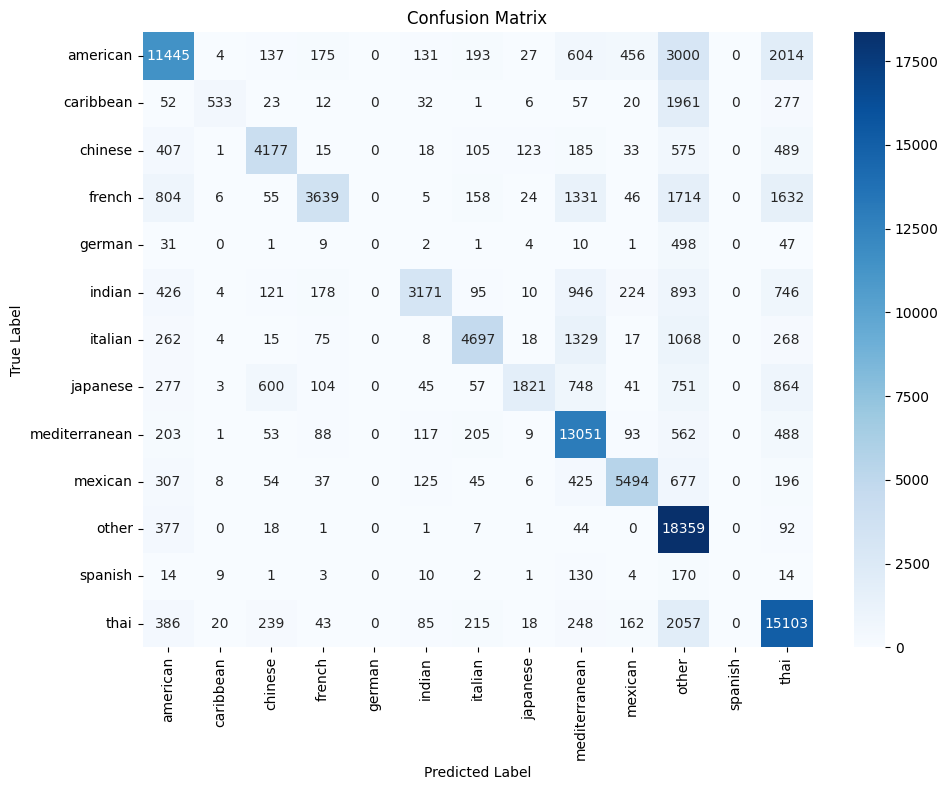

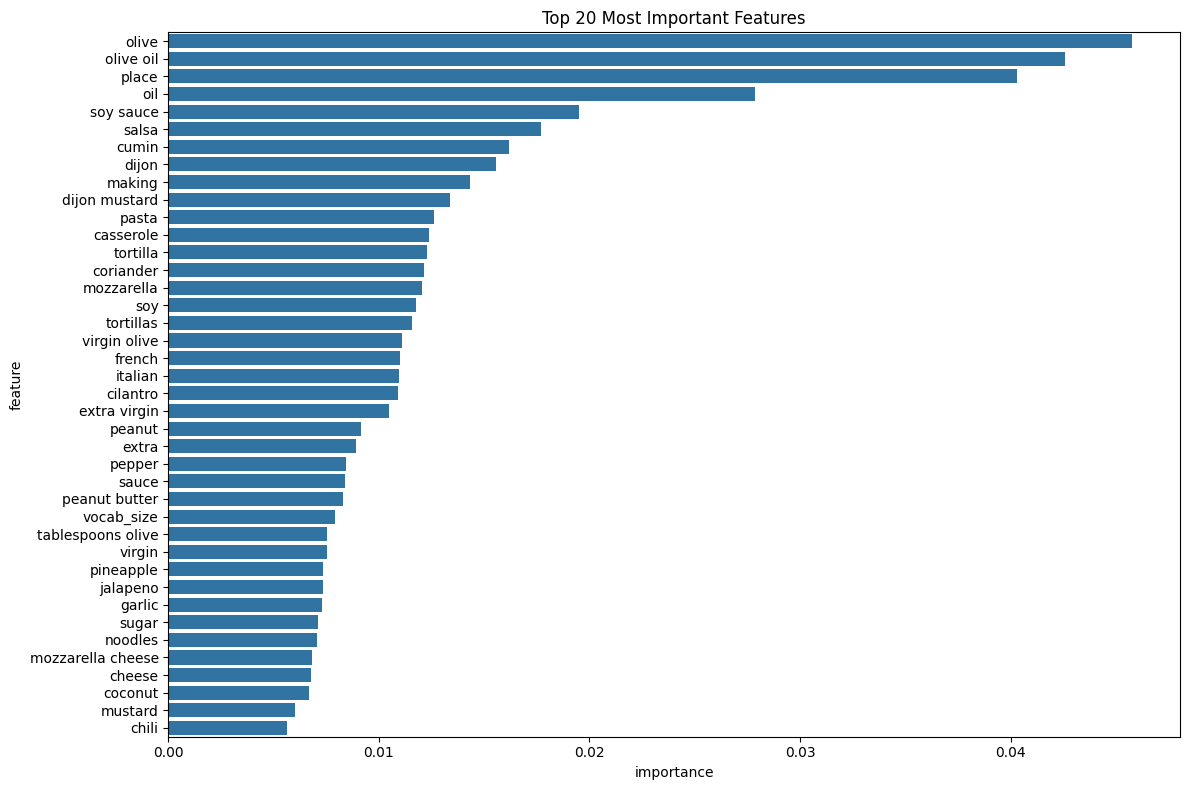

Feature importances saved to SaSha/cuisine_features//feature_importances.csv


In [ ]:
import numpy as np
import pandas as pd
from scipy import sparse
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

path_to_data = "SaSha/cuisine_features/"

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Get unique cuisine labels in the same order as in the confusion matrix
labels = np.unique(np.concatenate([y_test, y_pred]))

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(f"{path_to_data}confusion_matrix.png", dpi=300)
plt.show()

# Feature importance analysis
if hasattr(clf, 'feature_importances_'):
    # Get feature names (TF-IDF + vocab metrics)
    tfidf_features = []
    try:
        with open(f"{path_to_data}tfidf_feature_names.txt", 'r') as f:
            tfidf_features = [line.strip() for line in f]
    except:
        tfidf_features = [f"tfidf_{i}" for i in range(X_train_tfidf.shape[1])]

    vocab_features = vocab_train.columns.tolist()
    all_features = tfidf_features + vocab_features

    # Get feature importances
    importances = clf.feature_importances_

    # Create DataFrame for visualization
    feature_imp = pd.DataFrame({
        'feature': all_features[:len(importances)],
        'importance': importances
    }).sort_values('importance', ascending=False)

    # Plot top 20 features
    plt.figure(figsize=(12, 8))
    sns.barplot(x='importance', y='feature', data=feature_imp.head(40))
    plt.title('Top 20 Most Important Features')
    plt.tight_layout()
    plt.savefig(f"{path_to_data}feature_importance.png", dpi=300)
    plt.show()

    # Save feature importances
    feature_imp.to_csv(f"{path_to_data}feature_importances.csv", index=False)
    print(f"Feature importances saved to {path_to_data}/feature_importances.csv")

##### Normalized Confusion Matrix Visualization



- **Percentage-Based Analysis**: Creates row-normalized matrix showing classification success rates
- **Dual Annotations**: Displays both raw counts and percentages with adaptive text coloring

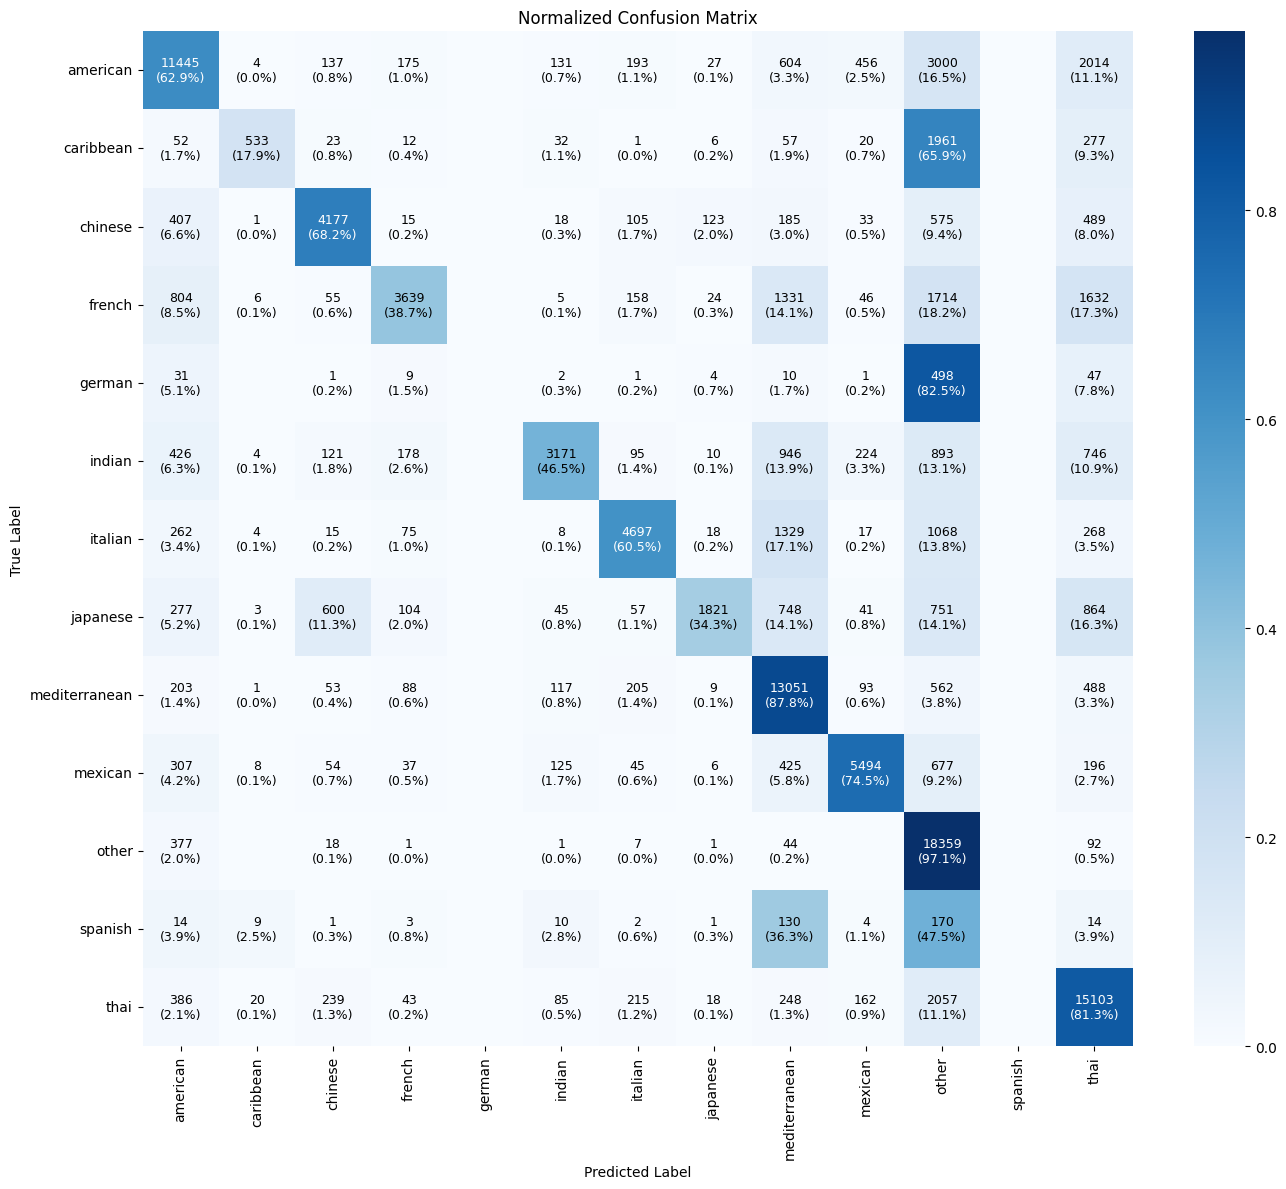

In [ ]:
# Calculate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Get unique cuisine labels in the same order as in the confusion matrix
labels = np.unique(np.concatenate([y_test, y_pred]))

# Create a normalized confusion matrix (by row/true label)
row_sums = conf_matrix.sum(axis=1, keepdims=True)
norm_conf_matrix = conf_matrix / row_sums  # Normalize by row (true label)

# Plot normalized confusion matrix
plt.figure(figsize=(14, 12))

# Plot normalized values as colors (percentages)
sns.heatmap(norm_conf_matrix, annot=False, cmap='Blues',
            xticklabels=labels, yticklabels=labels)

# Overlay the raw counts as text annotations
# Format with both count and percentage
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        if conf_matrix[i, j] > 0:
            # Display both count and percentage
            plt.text(j + 0.5, i + 0.5, f'{conf_matrix[i, j]}\n({norm_conf_matrix[i, j]:.1%})',
                     ha='center', va='center',
                     color='white' if norm_conf_matrix[i, j] > 0.5 else 'black',
                     fontsize=9)

plt.title('Normalized Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(f"{path_to_data}normalized_confusion_matrix.png", dpi=300)
plt.show()


## Word2vec exploration

### Load the model

In [ ]:
import numpy as np
from gensim.models import Word2Vec
import gc
import os

def load_word2vec_model(model_path):
    """
    Load a Word2Vec model from disk

    Args:
        model_path: Path to the saved model file

    Returns:
        Loaded Word2Vec model
    """
    print(f"Loading Word2Vec model from {model_path}")
    model = Word2Vec.load(model_path)
    print(f"Model loaded with vocabulary size: {len(model.wv)}")
    return model


# Example usage:
model_path = 'SaSha/W2V_models/recipe_word2vec_filtered.model'

# Load the model
model = load_word2vec_model(model_path)

# Do some operations with the model
try:
    print("\nExample: Words similar to 'chicken':")
    similar_words = model.wv.most_similar('chicken', topn=5)
    for word, similarity in similar_words:
        print(f"  {word}: {similarity:.4f}")
except KeyError:
    print("'chicken' not found in model vocabulary")

# If you have other large objects, keep references to free them
embeddings = None
if model is not None:
    # Example: create a large numpy array of word vectors
    words = list(model.wv.key_to_index.keys())[:1000]  # Get first 1000 words
    embeddings = np.array([model.wv[word] for word in words])
    print(f"\nCreated embeddings array with shape: {embeddings.shape}")


Loading Word2Vec model from SaSha/W2V_models/recipe_word2vec_filtered.model
Model loaded with vocabulary size: 31712

Example: Words similar to 'chicken':
  breasts: 0.6917
  chicen: 0.6543
  thighs: 0.6527
  ckn: 0.6368
  skineless: 0.6317

Created embeddings array with shape: (1000, 300)


### data preprocessing



1. **Data Filtering**
   - Filters the dataset to only include recipes from the "Recipes1M" source
   - Resets the index of the filtered dataframe to ensure proper sequential processing

2. **Text Preprocessing**
   - Converts text to lowercase
   - Removes special characters and numbers
   - Tokenizes text into individual words
   - Removes common stopwords (e.g., "the", "and", "is") and very short words

3. **Corpus Creation**
   - For each recipe, processes and combines tokens from:
     - Recipe title
     - List of ingredients
     - Cooking directions
   - Handles different data formats (strings vs lists)
   - Includes error handling to prevent processing failures


In [ ]:
import pandas as pd
import numpy as np
from gensim.models import Word2Vec
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords


# Assuming df is your original dataframe and filtered_df is your filtered dataframe
# Filter the dataframe to keep only recipes from the target source
target_source = "Recipes1M"
filtered_df = df[df['source'] == target_source]

# Check the size of your filtered dataset
print(f"Original dataset size: {len(df)} recipes")
print(f"Filtered dataset size: {len(filtered_df)} recipes")
print(f"Kept {len(filtered_df)/len(df)*100:.2f}% of the original data")
df = []

# Reset the index of the filtered dataframe
filtered_df = filtered_df.reset_index(drop=True)

# Function to clean and tokenize text
def clean_and_tokenize(text):
    if isinstance(text, list):
        text = ' '.join(text)
    elif not isinstance(text, str):
        return []

    # Convert to lowercase
    text = text.lower()

    # Remove special characters and digits
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', ' ', text)

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    filtered_tokens = [word for word in tokens if word not in stop_words and len(word) > 1]

    return filtered_tokens

# Prepare corpus for Word2Vec
corpus = []

# Process titles, ingredients, and directions using the filtered dataframe
for i in range(len(filtered_df)):
    try:
        # Process title
        title_tokens = clean_and_tokenize(filtered_df.loc[i, 'title'])

        # Process ingredients
        ingredients = filtered_df.loc[i, 'ingredients']
        if isinstance(ingredients, str):
            # If stored as string, convert to list
            ingredients = eval(ingredients)
        ingredients_tokens = clean_and_tokenize(ingredients)

        # Process directions
        directions = filtered_df.loc[i, 'directions']
        if isinstance(directions, str):
            # If stored as string, convert to list
            directions = eval(directions)
        directions_tokens = clean_and_tokenize(directions)

        # Combine all tokens for this recipe
        recipe_tokens = title_tokens + ingredients_tokens + directions_tokens

        if recipe_tokens:
            corpus.append(recipe_tokens)
    except Exception as e:
        print(f"Error processing recipe at index {i}: {e}")
        continue

print(f"Successfully processed {len(corpus)} recipes for Word2Vec training")
filtered_df = []


Original dataset size: 2231142 recipes
Filtered dataset size: 588044 recipes
Kept 26.36% of the original data
Successfully processed 588044 recipes for Word2Vec training


### Training Word2Vec Model on Recipe Dataset

This code trains a Word2Vec model on a the dataset to learn vector representations (embeddings) of cooking-related words. These embeddings capture semantic relationships between ingredients, cooking techniques, and other recipe elements.



#### Process Overview:
1. **Word2Vec Model Training**
   - Uses the Skip-gram architecture (better for infrequent words)
   - Creates 300-dimensional word vectors
   - Uses a context window of 5 words (considers 5 words before and after)
   - Ignores words that appear fewer than 5 times in the corpus
   - Utilizes 2 CPU threads for faster training

2. **Model Storage and Evaluation**
   - Saves the trained model to disk for future use
   - Displays basic statistics about the model
   - Tests the model by finding words semantically similar to "chicken"

This Word2Vec model can be used for various recipe analysis tasks, including:
- Finding ingredient substitutions
- Grouping similar cooking techniques
- Understanding relationships between ingredients
- Building recipe recommendation systems
- Enhancing recipe search functionality

The resulting word embeddings encode cooking knowledge in a numerical format that machine learning models can understand and utilize.

In [ ]:

# Train Word2Vec model
model = Word2Vec(
    sentences=corpus,
    vector_size=300,    # Dimensionality of the embeddings
    window=5,           # Maximum distance between current and predicted word
    min_count=5,        # Ignores words with frequency lower than this
    sg=1,               # Use skip-gram (1) rather than CBOW (0)
    workers=2           # Number of threads
)

# Save the model
model.save('SaSha/W2V_models/recipe_word2vec_filtered.model')

# Print some statistics about the model
print(f"Model vocabulary size: {len(model.wv)}")
print(f"Vector size: {model.wv.vector_size}")


Model vocabulary size: 31712
Vector size: 300


In [ ]:
# Try some examples
try:
    print("\nWords similar to 'chicken':")
    print(model.wv.most_similar('chicken', topn=10))
except KeyError:
    print("'chicken' not in vocabulary")

try:
    print("\nWords similar to 'bake':")
    print(model.wv.most_similar('bake', topn=10))
except:
    print("'bake' not in vocabulary or other error")



Words similar to 'chicken':
[('breasts', 0.691696047782898), ('chicen', 0.6542618870735168), ('thighs', 0.652729868888855), ('ckn', 0.6367916464805603), ('skineless', 0.6317233443260193), ('chiken', 0.6260790228843689), ('chicked', 0.6259944438934326), ('ckicken', 0.6233848333358765), ('chcken', 0.6075641512870789), ('breast', 0.604189395904541)]

Words similar to 'bake':
[('preheated', 0.6586449146270752), ('bakeat', 0.5697594285011292), ('degree', 0.548653781414032), ('bale', 0.5141155123710632), ('agreased', 0.5056964159011841), ('ffor', 0.5055810213088989), ('evely', 0.4930988848209381), ('nake', 0.48650556802749634), ('tester', 0.486070841550827), ('degreese', 0.48238644003868103)]


### 2D Plot word embeddings (colors are random)

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import random

def plot_embeddings(model, words=None, n=100, min_freq=None):
    """
    Plot word embeddings in 2D space using t-SNE

    Args:
        model: trained Word2Vec model
        words: list of words to plot (if None, use most common words)
        n: number of words to plot if words=None
        min_freq: if specified, only plot words that appear at least min_freq times
    """
    # Get embeddings
    if words is None:
        # Use top n most frequent words from the model
        if hasattr(model, 'wv') and hasattr(model.wv, 'key_to_index'):
            # For newer gensim versions
            valid_words = [word for word in model.wv.key_to_index]
        else:
            # For older gensim versions
            valid_words = [word for word in model.wv.vocab]

        # Sort by frequency if available
        if min_freq is not None and hasattr(model.wv, 'vocab'):
            valid_words = [word for word in valid_words if model.wv.vocab[word].count >= min_freq]

        # Take a sample if we have too many words
        if len(valid_words) > n:
            valid_words = valid_words[:n]
    else:
        # Filter to only include words in the vocabulary
        valid_words = [word for word in words if word in model.wv]
        print(f"Found {len(valid_words)}/{len(words)} words in vocabulary")

        # If we have too few words, add some common words from the model
        if len(valid_words) < 5:
            print("Adding more common words from vocabulary to make visualization meaningful")
            if hasattr(model, 'wv') and hasattr(model.wv, 'key_to_index'):
                extra_words = [w for w in list(model.wv.key_to_index)[:100] if w not in valid_words]
            else:
                extra_words = [w for w in list(model.wv.vocab)[:100] if w not in valid_words]

            valid_words.extend(extra_words[:min(30, len(extra_words))])

    # Make sure we have words to plot
    if not valid_words:
        print("No valid words found in vocabulary for visualization")
        return

    print(f"Generating visualization for {len(valid_words)} words")

    # Get the vector representations
    embeddings = np.array([model.wv[word] for word in valid_words])

    # Apply t-SNE for dimensionality reduction
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, max(5, len(valid_words)-1)))
    embeddings_2d = tsne.fit_transform(embeddings)

    # Plot with improved readability
    plt.figure(figsize=(16, 12))

    # Use different colors for different parts of speech or categories if possible
    colors = plt.cm.rainbow(np.linspace(0, 1, len(valid_words)))
    random.shuffle(colors)  # Shuffle colors for better distinction

    # Plot points
    plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=colors, alpha=0.7, s=100)

    # Add labels with improved position and readability
    for i, word in enumerate(valid_words):
        plt.annotate(
            word,
            xy=(embeddings_2d[i, 0], embeddings_2d[i, 1]),
            xytext=(5, 2),
            textcoords='offset points',
            fontsize=11,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.3)
        )

    # Add title and styling
    plt.title("Word Embeddings Visualization", fontsize=18)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()

    # Save and show
    plt.savefig('SaSha/W2V_models/word2vec_embeddings.png', dpi=300, bbox_inches='tight')
    plt.show()


#### Ploting selected words

Found 52/52 words in vocabulary
Generating visualization for 52 words


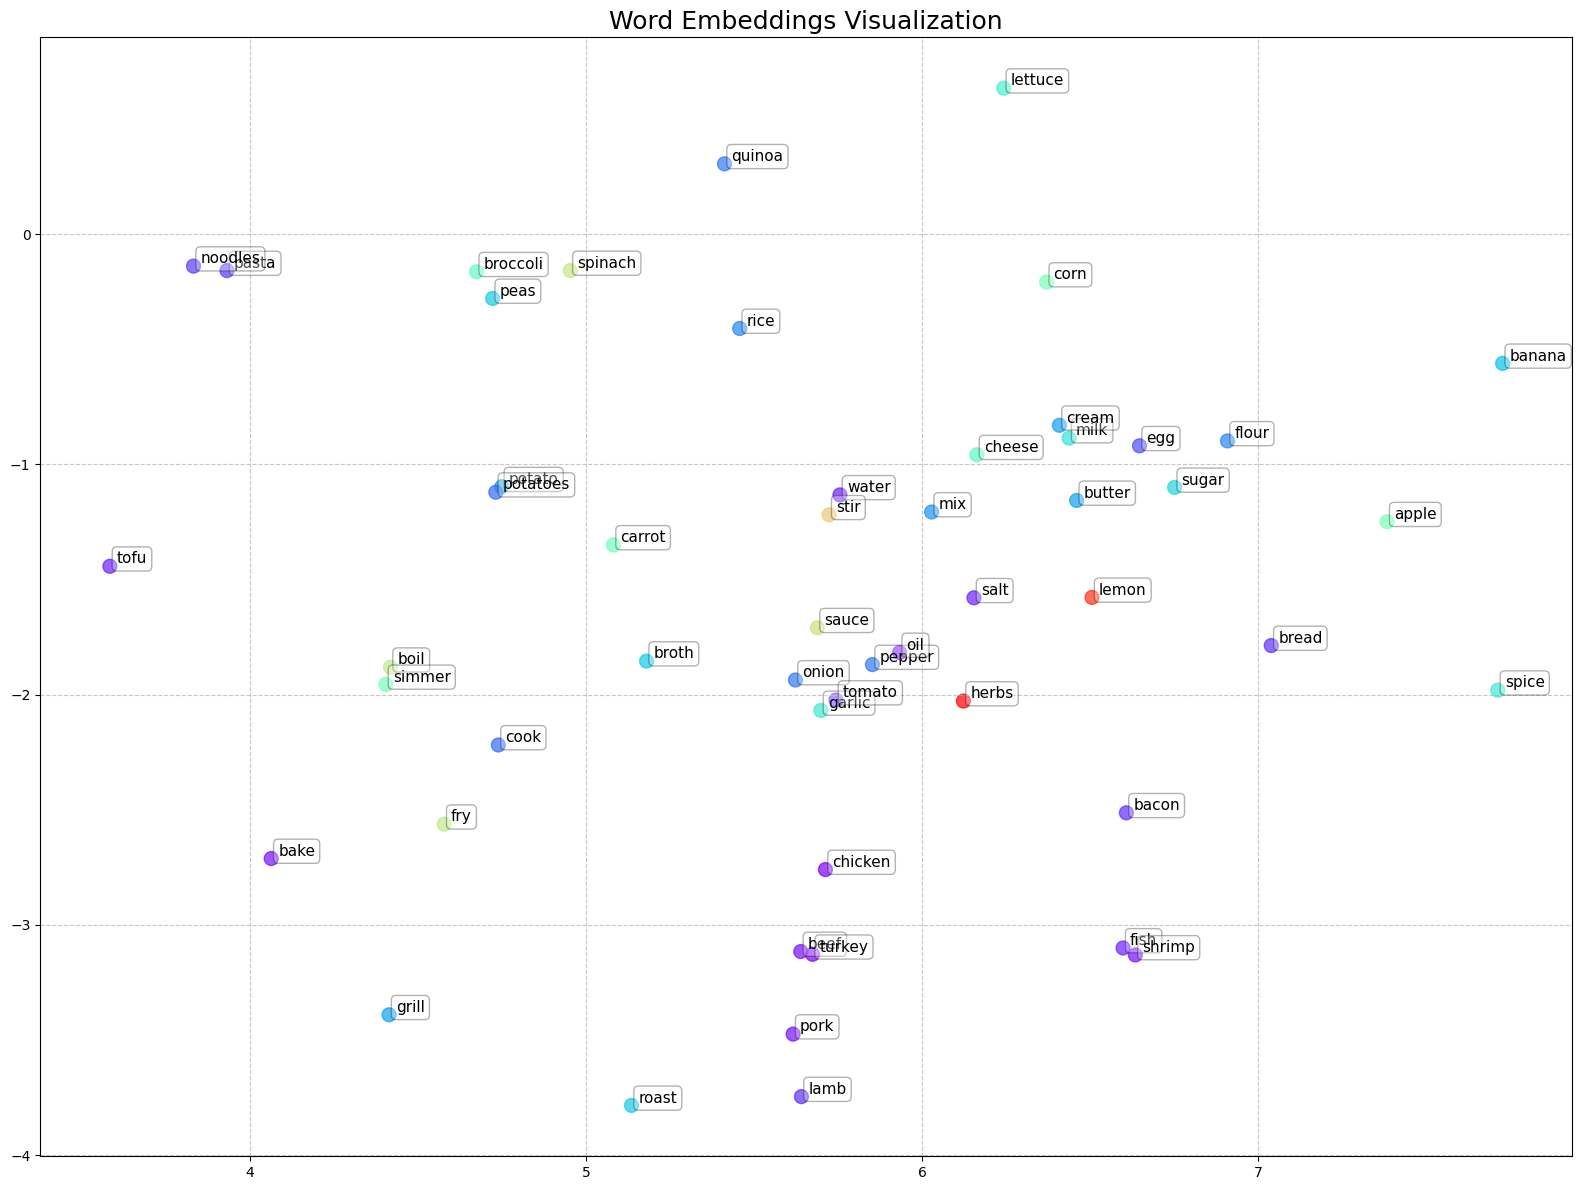

In [ ]:
# Enhanced list of common cooking ingredients and terms
cooking_words = [
    # Common proteins
    'chicken', 'beef', 'pork', 'fish', 'shrimp', 'tofu', 'turkey', 'lamb', 'bacon',

    # Starches/grains
    'rice', 'pasta', 'flour', 'bread', 'potato', 'potatoes', 'noodles', 'quinoa',

    # Basic ingredients
    'sugar', 'salt', 'pepper', 'oil', 'butter', 'milk', 'egg', 'cheese', 'cream',
    'garlic', 'onion', 'tomato', 'water', 'broth',

    # Cooking techniques
    'bake', 'boil', 'fry', 'roast', 'grill', 'simmer', 'stir', 'mix', 'cook',

    # Common vegetables
    'carrot', 'broccoli', 'spinach', 'lettuce', 'corn', 'peas',

    # Fruits
    'apple', 'banana', 'lemon',

    # Other
    'sauce', 'spice', 'herbs'
]

# Try the improved visualization function
try:
    plot_embeddings(model, words=cooking_words)
except Exception as e:
    print(f"Error plotting cooking words: {str(e)}")
    # Fall back to most common words
    try:
        print("\nFalling back to plotting most common words:")
        plot_embeddings(model, n=80)
    except Exception as e:
        print(f"Error plotting common words: {str(e)}")

#### Ploting top 100 most frequent words from the model

Generating visualization for 100 words


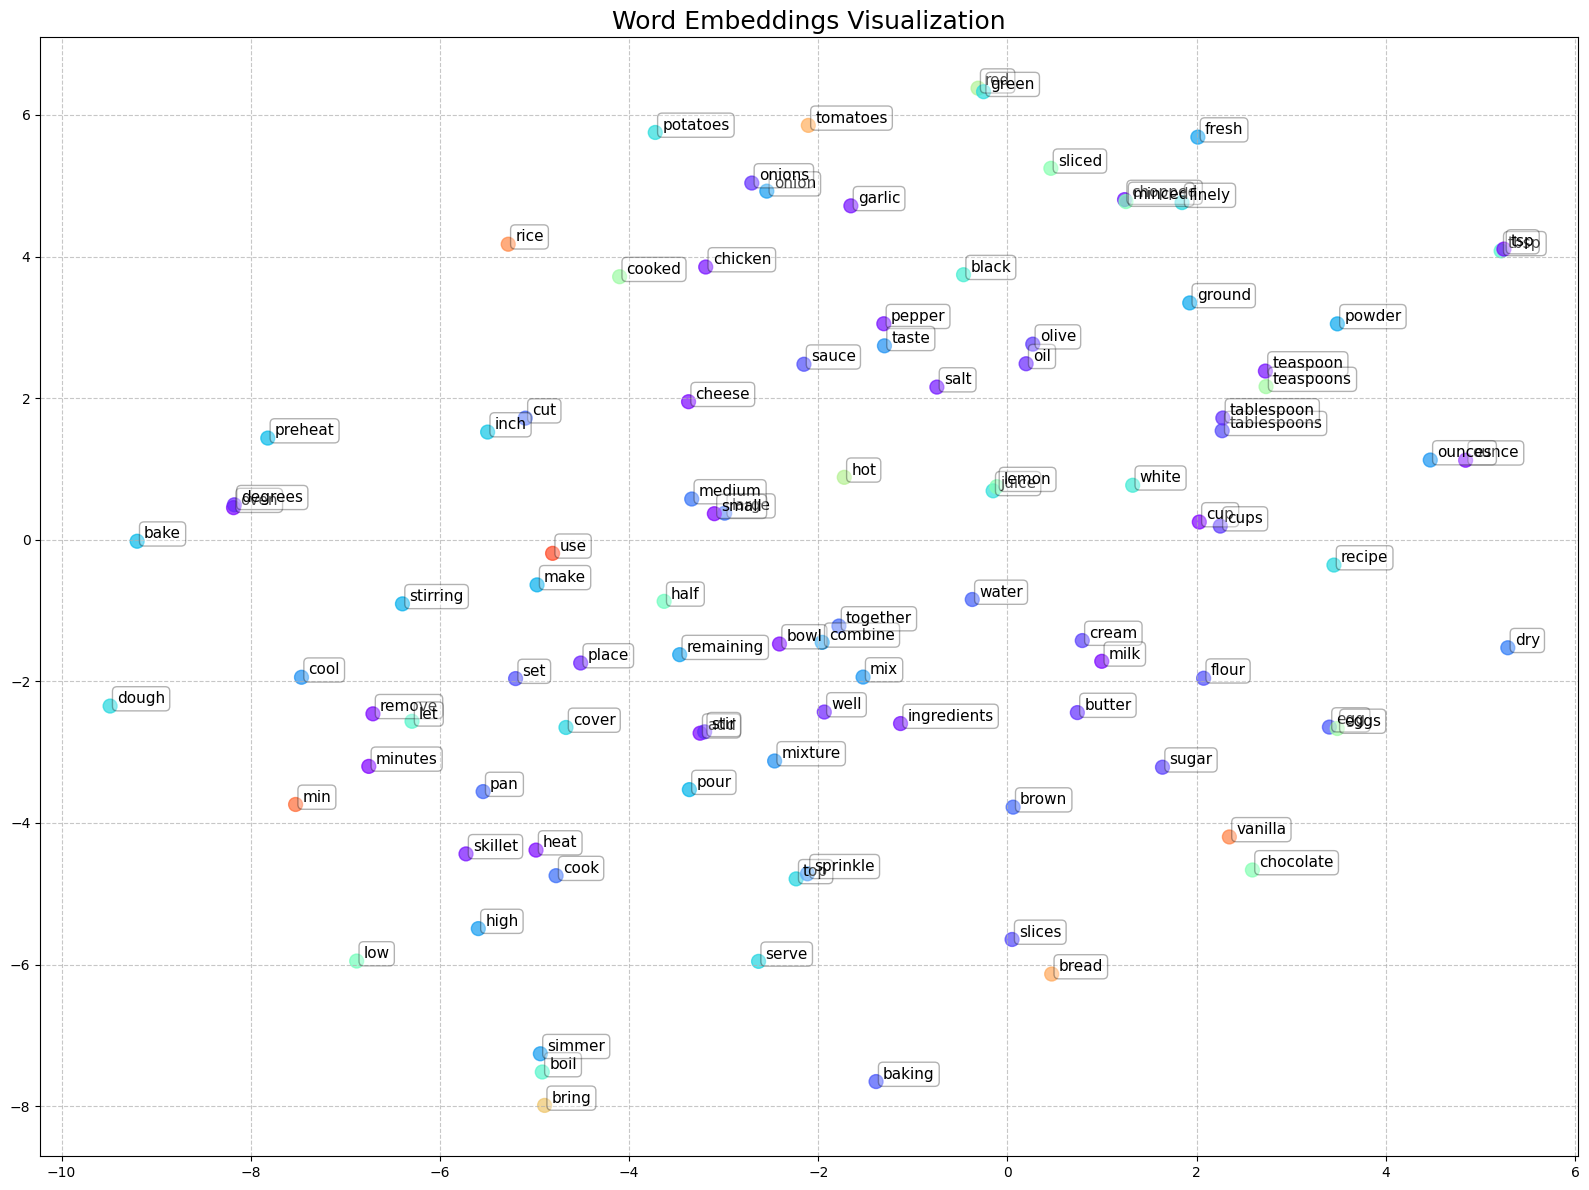

In [ ]:
plot_embeddings(model)

for selected words

### 3D Plot word embeddings

##### Implementation

In [ ]:
def plot_embeddings_3d(model, words=None, n=20, min_freq=None, range_limit=None,
                       categories=None, method='tsne', random_state=42):
    """
    Plot word embeddings in 3D space using various dimensionality reduction techniques

    Args:
        model: trained Word2Vec model
        words: list of words to plot (if None, use most common words)
        n: number of words to plot if words=None
        min_freq: if specified, only plot words that appear at least min_freq times
        range_limit: limit for the x, y, z axis range (-range_limit, range_limit)
        categories: dictionary mapping words to their categories for coloring
        method: dimensionality reduction method ('tsne', 'pca', 'umap', 'mds', 'isomap')
        random_state: random seed for reproducibility
    """
    import plotly.express as px
    import numpy as np
    import pandas as pd

    # Validate the method
    valid_methods = ['tsne', 'pca', 'umap', 'mds', 'isomap']
    if method.lower() not in valid_methods:
        print(f"Warning: Unknown method '{method}'. Using 'tsne' instead.")
        method = 'tsne'

    # Process words (get embeddings) - same as your original code
    if words is None:
        # Use top n most frequent words from the model
        if hasattr(model, 'wv') and hasattr(model.wv, 'key_to_index'):
            # For newer gensim versions
            valid_words = [word for word in model.wv.key_to_index]
        else:
            # For older gensim versions
            valid_words = [word for word in model.wv.vocab]

        # Sort by frequency if available
        if min_freq is not None and hasattr(model.wv, 'vocab'):
            valid_words = [word for word in valid_words if model.wv.vocab[word].count >= min_freq]

        # Take a sample if we have too many words
        if len(valid_words) > n:
            valid_words = valid_words[:n]
    else:
        # Filter to only include words in the vocabulary
        valid_words = [word for word in words if word in model.wv]
        print(f"Found {len(valid_words)}/{len(words)} words in vocabulary")

        # If we have too few words, add some common words from the model
        if len(valid_words) < 5:
            print("Adding more common words from vocabulary to make visualization meaningful")
            if hasattr(model, 'wv') and hasattr(model.wv, 'key_to_index'):
                extra_words = [w for w in list(model.wv.key_to_index)[:100] if w not in valid_words]
            else:
                extra_words = [w for w in list(model.wv.vocab)[:100] if w not in valid_words]

            valid_words.extend(extra_words[:min(30, len(extra_words))])

    # Make sure we have words to plot
    if not valid_words:
        print("No valid words found in vocabulary for visualization")
        return

    print(f"Generating 3D visualization for {len(valid_words)} words using {method.upper()}")

    # Get the vector representations
    embeddings = np.array([model.wv[word] for word in valid_words])

    # Apply dimensionality reduction based on the selected method
    if method.lower() == 'tsne':
        from sklearn.manifold import TSNE
        reducer = TSNE(n_components=3, random_state=random_state,
                     perplexity=min(15, max(5, len(valid_words)-1)),
                     learning_rate='auto', init='pca', n_iter=2000)

    elif method.lower() == 'pca':
        from sklearn.decomposition import PCA
        reducer = PCA(n_components=3, random_state=random_state)

    elif method.lower() == 'umap':
        try:
            import umap
            reducer = umap.UMAP(n_components=3, random_state=random_state,
                             min_dist=0.1, n_neighbors=min(15, max(5, len(valid_words)-1)))
        except ImportError:
            print("UMAP not installed. Please install with 'pip install umap-learn'")
            print("Falling back to PCA...")
            from sklearn.decomposition import PCA
            reducer = PCA(n_components=3, random_state=random_state)

    elif method.lower() == 'mds':
        from sklearn.manifold import MDS
        reducer = MDS(n_components=3, random_state=random_state, n_jobs=-1)

    elif method.lower() == 'isomap':
        from sklearn.manifold import Isomap
        n_neighbors = min(15, max(5, len(valid_words)-1))
        reducer = Isomap(n_components=3, n_neighbors=n_neighbors)

    # Apply the selected dimensionality reduction
    embeddings_3d = reducer.fit_transform(embeddings)

    # Extract x, y, z coordinates
    x, y, z = np.transpose(embeddings_3d)

    # Create a DataFrame for the data
    df = pd.DataFrame({
        'x': x,
        'y': y,
        'z': z,
        'word': valid_words,
    })

    # Add category information if provided
    if categories:
        df['category'] = df['word'].apply(lambda w: categories.get(w, 'Other'))
    else:
        df['category'] = 'All Words'

    # Auto-determine range if not specified
    if range_limit is None:
        # Calculate range with outlier protection (using 95th percentile)
        percentile_95 = np.percentile(np.abs(embeddings_3d), 95)

        if method == 'pca': scaler = 0.8
        elif method == 'umap': scaler = 1.1
        elif method == 'mds': scaler = 0.95
        elif method == 'isomap': scaler = 0.5
        else: scaler = 1.1 #tsne
        range_limit = percentile_95 * scaler  # Slightly larger than the 95th percentile

    # Set the range for the plot
    r = (-range_limit, range_limit)

    # Create the 3D scatter plot with color coding by category
    fig = px.scatter_3d(
        df,
        x='x', y='y', z='z',
        range_x=r, range_y=r, range_z=r,
        text='word',
        color='category',
        opacity=0.8,
        title=f"Word Embeddings 3D Visualization ({method.upper()})"
    )

    # Update trace properties for better visualization
    fig.update_traces(
        marker=dict(size=6, line=dict(width=1)),
        textfont_size=10,
        selector=dict(mode='markers+text')
    )

    # Add title
    fig.update_layout(
        title_x=0.5,
        title_font_size=18,
        legend_title="Category",
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z'
        )
    )

    # Return the figure so it can be shown or saved
    return fig

#### 3D Ploting selected words

In [ ]:
cooking_categories = {
    # Meat (sea animal)
    'fish': 'Meats (sea)',
    'shrimp': 'Meats (sea)',

    # Meats (animal proteins)
    'pork': 'Meats',
    'turkey': 'Meats',
    'lamb': 'Meats',
    'bacon': 'Meats',

    # Fruits
    'apple': 'Fruits',
    'banana': 'Fruits',
    'lemon': 'Fruits',


    # Vegetables
    'carrot': 'Vegetables',
    'broccoli': 'Vegetables',
    'spinach': 'Vegetables',
    'lettuce': 'Vegetables',
    'corn': 'Vegetables',
    'peas': 'Vegetables',
    'tomato': 'Vegetables',
    'potato': 'Vegetables',
    'garlic': 'Vegetables',
    'onion': 'Vegetables',

}

# Using PCA (fastest method, preserves global structure)
fig_pca = plot_embeddings_3d(model, words=list(cooking_categories.keys()), categories=cooking_categories, method='pca')
fig_pca.show()

# Using UMAP (better at preserving both local and global structure)
fig_umap = plot_embeddings_3d(model, words=list(cooking_categories.keys()), categories=cooking_categories, method='umap')
fig_umap.show()

# Using MDS (preserves pairwise distances)
fig_mds = plot_embeddings_3d(model, words=list(cooking_categories.keys()), categories=cooking_categories, method='mds')
fig_mds.show()

# Using Isomap (preserves geodesic distances)
fig_isomap = plot_embeddings_3d(model, words=list(cooking_categories.keys()), categories=cooking_categories, method='isomap')
fig_isomap.show()

# Using Isomap (preserves geodesic distances)
fig_isomap = plot_embeddings_3d(model, words=list(cooking_categories.keys()), categories=cooking_categories, method='tsne')
fig_isomap.show()

Found 19/19 words in vocabulary
Generating 3D visualization for 19 words using PCA


Found 19/19 words in vocabulary
Generating 3D visualization for 19 words using UMAP


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Found 19/19 words in vocabulary
Generating 3D visualization for 19 words using MDS


Found 19/19 words in vocabulary
Generating 3D visualization for 19 words using ISOMAP


Found 19/19 words in vocabulary
Generating 3D visualization for 19 words using TSNE


/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



#### 3D Ploting top 30 most frequent words from the model

In [ ]:
# Using PCA (fastest method, preserves global structure)
fig_pca = plot_embeddings_3d(model, n=30, method='pca')
fig_pca.show()

# Using UMAP (better at preserving both local and global structure)
fig_umap = plot_embeddings_3d(model, n=30, method='umap')
fig_umap.show()

# Using MDS (preserves pairwise distances)
fig_mds = plot_embeddings_3d(model, n=30, method='mds')
fig_mds.show()

# Using Isomap (preserves geodesic distances)
fig_isomap = plot_embeddings_3d(model, n=30, method='isomap')
fig_isomap.show()

Generating 3D visualization for 30 words using PCA


Generating 3D visualization for 30 words using UMAP


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Generating 3D visualization for 30 words using MDS


Generating 3D visualization for 30 words using ISOMAP


## Indexing Recipes for Recipe Search and Chatbot Interface

This section implements an intelligent recipe search system with an interactive chat interface, allowing users to find recipes based on ingredients, cooking techniques, or meal types.

**Implementation Overview**

- **Search Engine Architecture**:
  * Dual indexing methods: BM25 (term frequency weighting) and TF-IDF (term importance weighting)
  * Memory-efficient design with model persistence for large recipe collections
  * Hybrid search capabilities combining both algorithms for optimal results

- **Key Features**:
  * Natural language query processing with stopword removal
  * Interactive chatbot interface with command system
  * Detailed and summarized recipe viewing options
  * Adjustable search parameters (result count, search algorithm, detail level)

- **Performance Optimization**:
  * Tokenization and preprocessing of recipe text for faster search
  * Persistent storage of search indices to avoid retraining
  * Score normalization and weighting for balanced hybrid results

### loading data (only when you want to train. Not required for chatbox)

In [ ]:
import pandas as pd

# Define the path to load the filtered DataFrame
load_path = '/content/drive/MyDrive/rcp-nlp/filtered_recipes1m.pkl'

# Load the filtered DataFrame from the pickle file
filtered_df = pd.read_pickle(load_path)

print(f"Filtered DataFrame loaded from: {load_path}")
print(f"Filtered dataset shape: {filtered_df.shape}")

# Display the first few rows of the loaded DataFrame
print("\nFirst 5 rows of the loaded DataFrame:")
print(filtered_df.head())

### Recipe Search Engine

- **Core Components**:
  * Multi-algorithm search engine class with BM25 and TF-IDF indexing methods
  * Persistent model storage system to save and load indices
  * Text preprocessing with stopword removal and tokenization

- **BM25 Implementation**:
  * Implements Okapi BM25 algorithm optimized for recipe search
  * Tokenizes and filters recipe text (title, ingredients, directions)
  * Saves tokenized recipes and index models for fast reloading

- **TF-IDF Implementation**:
  * Creates vector representations of recipe documents
  * Configures TfidfVectorizer with optimal parameters for recipe domain
  * Implements sublinear term frequency scaling for better results

- **Hybrid Search Algorithm**:
  * Combines BM25 and TF-IDF results with configurable weighting
  * Normalizes scores between algorithms for fair comparison
  * Returns comprehensive result objects with dual scoring metrics

- **Performance Features**:
  * Dataset sampling capability for faster development
  * Execution timing for performance monitoring
  * Memory-efficient model loading and searching

In [ ]:
import pickle
import os
import numpy as np
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import time

class RecipeSearchEngine:
    """Recipe search engine with BM25 and TF-IDF search methods and model persistence"""

    def __init__(self, model_dir="SaSha/recipe_search_models"):
        """Initialize the search engine with model directory for persistence"""
        self.model_dir = model_dir
        self.bm25_loaded = False
        self.tfidf_loaded = False
        self.df_index = None

        # Create model directory if it doesn't exist
        if not os.path.exists(model_dir):
            os.makedirs(model_dir)

    def train_bm25_index(self, df, max_recipes=None, random_state=42):
        """Train BM25 search model and save it to disk"""
        from rank_bm25 import BM25Okapi

        print("\n=== Training BM25 Index ===")
        start_time = time.time()

        # Sample data if needed
        if max_recipes is not None and len(df) > max_recipes:
            print(f"Using a sample of {max_recipes} recipes from {len(df)} total")
            df_index = df.sample(max_recipes, random_state=random_state)
        else:
            print(f"Using all {len(df)} recipes")
            df_index = df.copy()

        # Get English stopwords
        stop_words = set(stopwords.words('english'))

        # Tokenize documents for indexing
        print("Tokenizing recipes...")
        tokenized_recipes = []

        for _, row in df_index.iterrows():
            # Combine all text from the recipe
            recipe_text = row['title'] + ' ' + ' '.join(row['ingredients']) + ' ' + ' '.join(row['directions'])

            # Tokenize and filter out stopwords and non-alphanumeric tokens
            tokens = word_tokenize(recipe_text.lower())
            filtered_tokens = [token for token in tokens if token.isalnum() and token not in stop_words]

            tokenized_recipes.append(filtered_tokens)

        # Create BM25 index
        print("Building BM25 index...")
        bm25_index = BM25Okapi(tokenized_recipes)

        print(f"BM25 indexing completed in {time.time() - start_time:.2f} seconds")
        print(f"Indexed {len(df_index)} recipes with {sum(len(doc) for doc in tokenized_recipes)} total tokens")

        # Store the models in memory
        self.bm25_index = bm25_index
        self.tokenized_recipes = tokenized_recipes

        # Save the dataframe if it's not already saved
        if self.df_index is None:
            self.df_index = df_index
            with open(f"{self.model_dir}/df_index.pkl", 'wb') as f:
                pickle.dump(self.df_index, f)
                print(f"Saved DataFrame with indexed recipes {self.model_dir}/df_index.pkl")

        # Save the models
        with open(f"{self.model_dir}/bm25_index.pkl", 'wb') as f:
            pickle.dump(bm25_index, f)

        with open(f"{self.model_dir}/tokenized_recipes.pkl", 'wb') as f:
            pickle.dump(tokenized_recipes, f)

        self.bm25_loaded = True
        print(f"BM25 model trained and saved successfully! \n{self.model_dir} \n  -bm25_index.pkl \n  -tokenized_recipes.pkl")

        return bm25_index, tokenized_recipes

    def train_tfidf_index(self, df, max_recipes=None, random_state=42):
        """Train TF-IDF search model and save it to disk"""
        from sklearn.feature_extraction.text import TfidfVectorizer

        print("\n=== Training TF-IDF Index ===")
        start_time = time.time()

        # Sample data if needed
        if max_recipes is not None and len(df) > max_recipes:
            print(f"Using a sample of {max_recipes} recipes from {len(df)} total")
            df_index = df.sample(max_recipes, random_state=random_state)
        else:
            print(f"Using all {len(df)} recipes")
            df_index = df.copy()

        # Prepare documents for indexing
        print("Preparing recipe documents...")
        recipe_docs = []

        for _, row in df_index.iterrows():
            # Combine all text from the recipe
            recipe_text = row['title'] + ' ' + ' '.join(row['ingredients']) + ' ' + ' '.join(row['directions'])
            recipe_docs.append(recipe_text)

        # Create TF-IDF vectorizer and transform documents
        print("Building TF-IDF index...")
        tfidf_vectorizer = TfidfVectorizer(
            stop_words='english',
            min_df=2,  # Ignore terms that appear in less than 2 documents
            max_df=0.9,  # Ignore terms that appear in more than 90% of the documents
            sublinear_tf=True  # Apply sublinear tf scaling (1 + log(tf))
        )

        tfidf_matrix = tfidf_vectorizer.fit_transform(recipe_docs)

        print(f"TF-IDF indexing completed in {time.time() - start_time:.2f} seconds")
        print(f"Indexed {len(df_index)} recipes with {tfidf_matrix.shape[1]} features")

        # Store the models in memory
        self.tfidf_vectorizer = tfidf_vectorizer
        self.tfidf_matrix = tfidf_matrix

        # Save the dataframe if it's not already saved
        if self.df_index is None:
            self.df_index = df_index
            with open(f"{self.model_dir}/df_index.pkl", 'wb') as f:
                pickle.dump(self.df_index, f)
                print("Saved DataFrame with indexed recipes")

        # Save the models
        with open(f"{self.model_dir}/tfidf_vectorizer.pkl", 'wb') as f:
            pickle.dump(tfidf_vectorizer, f)

        with open(f"{self.model_dir}/tfidf_matrix.pkl", 'wb') as f:
            pickle.dump(tfidf_matrix, f)

        self.tfidf_loaded = True
        print("TF-IDF model trained and saved successfully!")

        return tfidf_vectorizer, tfidf_matrix

    def load_bm25_index(self):
        """Load BM25 model from disk"""
        if not os.path.exists(f"{self.model_dir}/bm25_index.pkl"):
            print("BM25 model has not been trained yet. Please run train_bm25_index first.")
            return False

        print("Loading BM25 model from disk...")
        start_time = time.time()

        # Load the models
        with open(f"{self.model_dir}/bm25_index.pkl", 'rb') as f:
            self.bm25_index = pickle.load(f)

        with open(f"{self.model_dir}/tokenized_recipes.pkl", 'rb') as f:
            self.tokenized_recipes = pickle.load(f)

        # Load the DataFrame if not already loaded
        if self.df_index is None:
            with open(f"{self.model_dir}/df_index.pkl", 'rb') as f:
                self.df_index = pickle.load(f)

        self.bm25_loaded = True
        print(f"BM25 model loaded successfully in {time.time() - start_time:.2f} seconds!")
        return True

    def load_tfidf_index(self):
        """Load TF-IDF model from disk"""
        if not os.path.exists(f"{self.model_dir}/tfidf_vectorizer.pkl"):
            print("TF-IDF model has not been trained yet. Please run train_tfidf_index first.")
            return False

        print("Loading TF-IDF model from disk...")
        start_time = time.time()

        # Load the models
        with open(f"{self.model_dir}/tfidf_vectorizer.pkl", 'rb') as f:
            self.tfidf_vectorizer = pickle.load(f)

        with open(f"{self.model_dir}/tfidf_matrix.pkl", 'rb') as f:
            self.tfidf_matrix = pickle.load(f)

        # Load the DataFrame if not already loaded
        if self.df_index is None:
            with open(f"{self.model_dir}/df_index.pkl", 'rb') as f:
                self.df_index = pickle.load(f)

        self.tfidf_loaded = True
        print(f"TF-IDF model loaded successfully in {time.time() - start_time:.2f} seconds!")
        return True

    def search_bm25(self, query, top_k=5):
        """Search recipes using BM25"""
        if not self.bm25_loaded:
            if not self.load_bm25_index():
                return []

        # Get English stopwords
        stop_words = set(stopwords.words('english'))

        # Tokenize and filter the query
        query_tokens = word_tokenize(query.lower())
        filtered_query = [token for token in query_tokens if token.isalnum() and token not in stop_words]

        # Get BM25 scores
        scores = self.bm25_index.get_scores(filtered_query)

        # Get indices of top results
        top_indices = np.argsort(scores)[::-1][:top_k]

        # Prepare results
        results = []
        for idx in top_indices:
            recipe = self.df_index.iloc[idx]
            results.append({
                "title": recipe["title"],
                "score": scores[idx],
                "ingredients": recipe["ingredients"],
                "directions": recipe["directions"],
                "method": "BM25"
            })

        return results

    def search_tfidf(self, query, top_k=5):
        """Search recipes using TF-IDF similarity"""
        if not self.tfidf_loaded:
            if not self.load_tfidf_index():
                return []

        from sklearn.metrics.pairwise import cosine_similarity

        # Transform query to TF-IDF features
        query_vector = self.tfidf_vectorizer.transform([query])

        # Calculate cosine similarity between query and all recipes
        cosine_similarities = cosine_similarity(query_vector, self.tfidf_matrix).flatten()

        # Get indices of top results
        top_indices = np.argsort(cosine_similarities)[::-1][:top_k]

        # Prepare results
        results = []
        for idx in top_indices:
            recipe = self.df_index.iloc[idx]
            results.append({
                "title": recipe["title"],
                "score": float(cosine_similarities[idx]),
                "ingredients": recipe["ingredients"],
                "directions": recipe["directions"],
                "method": "TF-IDF"
            })

        return results

    def search_hybrid(self, query, top_k=5, bm25_weight=0.6):
        """Search recipes using a hybrid of BM25 and TF-IDF with weighted scores"""
        if not self.bm25_loaded or not self.tfidf_loaded:
            missing = []
            if not self.bm25_loaded:
                if not self.load_bm25_index():
                    missing.append("BM25")
            if not self.tfidf_loaded:
                if not self.load_tfidf_index():
                    missing.append("TF-IDF")

            if missing:
                print(f"Cannot perform hybrid search. Missing models: {', '.join(missing)}")
                return []

        from sklearn.metrics.pairwise import cosine_similarity

        # Get English stopwords
        stop_words = set(stopwords.words('english'))

        # Tokenize and filter the query for BM25
        query_tokens = word_tokenize(query.lower())
        filtered_query = [token for token in query_tokens if token.isalnum() and token not in stop_words]

        # Get BM25 scores
        bm25_scores = np.array(self.bm25_index.get_scores(filtered_query))

        # Normalize BM25 scores to [0,1] range if there are non-zero scores
        if bm25_scores.max() > 0:
            bm25_scores = bm25_scores / bm25_scores.max()

        # Get TF-IDF similarity scores
        query_tfidf = self.tfidf_vectorizer.transform([query])
        tfidf_scores = cosine_similarity(query_tfidf, self.tfidf_matrix).flatten()

        # Combine scores with weighting
        combined_scores = (bm25_weight * bm25_scores) + ((1 - bm25_weight) * tfidf_scores)

        # Get indices of top results
        top_indices = np.argsort(combined_scores)[::-1][:top_k]

        # Prepare results
        results = []
        for idx in top_indices:
            recipe = self.df_index.iloc[idx]
            results.append({
                "title": recipe["title"],
                "score": float(combined_scores[idx]),
                "bm25_score": float(bm25_scores[idx]),
                "tfidf_score": float(tfidf_scores[idx]),
                "ingredients": recipe["ingredients"],
                "directions": recipe["directions"],
                "method": "Hybrid"
            })

        return results



### Interactive Recipe Chatbot Interface

- **Result Display Functions**:
  * `display_results()`: Shows summarized recipe search results with relevance scores
  * `display_full_recipe()`: Presents complete recipe with formatted ingredients and directions
  * Uses emoji and formatting to enhance readability

- **Interactive Chat System**:
  * Implements command-based interface with special commands prefixed with `!`
  * Provides help system with `!help` command listing available options
  * Maintains session state (current results, search method, display preferences)

- **User Experience Features**:
  * Allows numeric input to select and view detailed recipes
  * Supports toggling between summary and detailed views
  * Enables customizing search parameters like result count
  * Provides search method selection (BM25, TF-IDF, or hybrid)

- **System Infrastructure**:
  * Automatically detects and loads available search models
  * Gracefully handles missing models with informative error messages
  * Maintains current result set for immediate access to recipes

In [ ]:
def display_results(results, detailed=False):
    """Display search results in a formatted way"""
    if not results:
        print("No results found.")
        return

    print(f"\nFound {len(results)} matching recipes:")
    print("-" * 60)

    for i, recipe in enumerate(results):
        print(f"{i+1}. {recipe['title']} (Score: {recipe['score']:.4f})")

        if 'bm25_score' in recipe and 'tfidf_score' in recipe:
            print(f"   BM25: {recipe['bm25_score']:.4f}, TF-IDF: {recipe['tfidf_score']:.4f}")

        print(f"   Ingredients: {', '.join(recipe['ingredients'][:3])}...")

        if detailed:
            print(f"   All Ingredients: {', '.join(recipe['ingredients'])}")
            print(f"   Directions:")
            for j, step in enumerate(recipe['directions'][:3]):
                print(f"      {j+1}. {step[:100]}...")
        else:
            print(f"   Directions: {recipe['directions'][0][:100]}...")

        print("-" * 60)

    print("To view full recipe details, enter the recipe number (e.g., 1, 2, 3)")

def display_full_recipe(recipe):
    """Display a complete recipe with all details"""
    print("\n" + "=" * 80)
    print(f"🍳  {recipe['title']}  🍳")
    print("=" * 80)

    # Display score if available
    if 'score' in recipe:
        print(f"Search relevance score: {recipe['score']:.4f}")
        if 'bm25_score' in recipe and 'tfidf_score' in recipe:
            print(f"BM25 score: {recipe['bm25_score']:.4f}, TF-IDF score: {recipe['tfidf_score']:.4f}")
    print()

    # Display ingredients
    print("📋 INGREDIENTS:")
    print("-" * 80)
    for ingredient in recipe['ingredients']:
        print(f"• {ingredient}")
    print()

    # Display directions
    print("👨‍🍳 DIRECTIONS:")
    print("-" * 80)
    for i, step in enumerate(recipe['directions']):
        print(f"Step {i+1}: {step}")

    print("\n" + "=" * 80)

def recipe_search_chat():
    """Interactive chat-like interface for recipe search"""
    import os

    # Create the search engine
    search_engine = RecipeSearchEngine()

    # Check if models are already trained
    models_exist = os.path.exists(f"{search_engine.model_dir}/bm25_index.pkl") or \
                   os.path.exists(f"{search_engine.model_dir}/tfidf_vectorizer.pkl")

    if not models_exist:
        print("No trained models found. Please train models before using the search chat.")
        return

    # Try to load the models
    bm25_loaded = search_engine.load_bm25_index()
    tfidf_loaded = search_engine.load_tfidf_index()

    available_methods = []
    if bm25_loaded:
        available_methods.append("bm25")
    if tfidf_loaded:
        available_methods.append("tfidf")
    if bm25_loaded and tfidf_loaded:
        available_methods.append("hybrid")

    if not available_methods:
        print("Failed to load any search models. Please train models before using the search chat.")
        return

    print("\n" + "=" * 70)
    print(f"🍽️  Recipe Search Chat 🍽️")
    print("=" * 70)
    print("Type your search query to find matching recipes.")
    print("Special commands:")
    print("  !help      - Show this help message")
    print("  !method    - Change search method")
    print("  !detail    - Toggle detailed view")
    print("  !top       - Change number of results")
    print("  !quit      - Exit the chat")
    print("After searching, enter the recipe number to view full details")
    print("=" * 70)

    current_method = "hybrid" if "hybrid" in available_methods else available_methods[0]
    top_k = 5
    detailed_view = False
    current_results = []

    print(f"Current search method: {current_method.upper()}")
    print(f"Showing top {top_k} results, detailed view is {'ON' if detailed_view else 'OFF'}")

    while True:
        print("\nWhat recipes are you looking for today? 👩‍🍳")
        print("(Type a number to view full recipe, or enter a search query)")
        query = input("> ").strip()

        if not query:
            continue

        # Check if user wants to view a recipe from the current results
        if current_results and query.isdigit():
            recipe_num = int(query)
            if 1 <= recipe_num <= len(current_results):
                # Display the full recipe
                display_full_recipe(current_results[recipe_num-1])
                print("\nEnter a new search query, or type !help for options")
                continue
            else:
                print(f"Please enter a valid recipe number between 1 and {len(current_results)}")
                continue

        # Handle special commands
        if query.lower() == "!quit" or query.lower() == "!exit":
            print("Thanks for searching recipes! Goodbye! 👋")
            break

        elif query.lower() == "!help":
            print("\n" + "=" * 70)
            print("Available commands:")
            print("  !help      - Show this help message")
            print("  !method    - Change search method")
            print("  !detail    - Toggle detailed view")
            print("  !top       - Change number of results")
            print("  !quit      - Exit the chat")
            print("After searching, enter the recipe number to view full details")
            print("=" * 70)
            print(f"Current search method: {current_method.upper()}")
            print(f"Showing top {top_k} results, detailed view is {'ON' if detailed_view else 'OFF'}")
            continue

        elif query.lower() == "!method":
            print(f"\nAvailable search methods: {', '.join([m.upper() for m in available_methods])}")
            print(f"Current method: {current_method.upper()}")
            new_method = input("Enter new search method: ").strip().lower()

            if new_method in available_methods:
                current_method = new_method
                print(f"Search method changed to {current_method.upper()}")
            else:
                print(f"Invalid method. Available methods: {', '.join(available_methods)}")
            continue

        elif query.lower() == "!detail":
            detailed_view = not detailed_view
            print(f"Detailed view is now {'ON' if detailed_view else 'OFF'}")
            continue

        elif query.lower() == "!top":
            try:
                new_top_k = int(input(f"Current top results: {top_k}. Enter new value: ").strip())
                if new_top_k > 0:
                    top_k = new_top_k
                    print(f"Now showing top {top_k} results")
                else:
                    print("Please enter a positive number")
            except ValueError:
                print("Please enter a valid number")
            continue

        # Perform the search based on the selected method
        print(f"\nSearching for '{query}' using {current_method.upper()} method...")

        if current_method == "bm25":
            current_results = search_engine.search_bm25(query, top_k)
        elif current_method == "tfidf":
            current_results = search_engine.search_tfidf(query, top_k)
        elif current_method == "hybrid":
            current_results = search_engine.search_hybrid(query, top_k)

        # Display results
        display_results(current_results, detailed_view)

### methods

##### training models

In [ ]:

    # Example of training models (uncomment these lines for first-time use,
    # note that due to Memmory limit, only train one model at a time)

    # search_engine = RecipeSearchEngine()
    # search_engine.train_bm25_index(filtered_df, max_recipes=None)
    # search_engine.train_tfidf_index(filtered_df, max_recipes=None)


 ##### Start the interactive chat

In [ ]:
recipe_search_chat()

Loading BM25 model from disk...
BM25 model loaded successfully in 66.22 seconds!
Loading TF-IDF model from disk...
TF-IDF model loaded successfully in 2.53 seconds!

🍽️  Recipe Search Chat 🍽️
Type your search query to find matching recipes.
Special commands:
  !help      - Show this help message
  !method    - Change search method
  !detail    - Toggle detailed view
  !top       - Change number of results
  !quit      - Exit the chat
After searching, enter the recipe number to view full details
Current search method: HYBRID
Showing top 5 results, detailed view is OFF

What recipes are you looking for today? 👩‍🍳
(Type a number to view full recipe, or enter a search query)
> egg

Searching for 'egg' using HYBRID method...

Found 5 matching recipes:
------------------------------------------------------------
1. Boiled Egg Recipe (Score: 0.7490)
   BM25: 0.9686, TF-IDF: 0.4197
   Ingredients: Egg, Water...
   Directions: Remove egg from refrigerator....
-----------------------------------

KeyboardInterrupt: Interrupted by user

# 2.Training models

#  3.Possible extensions:
